In [2]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [3]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [4]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog

In [5]:
#Import data
from load_data import load_data

indep_vars, dep_vars = load_data('../AirFogSim/output/global_data.csv')

In [ ]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 3 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, average V2U density, average compute load and the previous average compute load. 
- Independent variable (x1): Current task success ratio
- Independent variable (x2): Current vehicle density
- Independent variable (x3): Current average V2U density
- Independent variable (x4): Average compute load at the current time slot (i.e., y_t)
- Independent variable (x5): Average compute load at the previous time slot (i.e., y_{t-1})
- Dependent variable (y): Average compute load at the next time slot (i.e., y_{t+1})

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
"""

In [6]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, average V2U density, average compute load and the previous average compute load. 
- Independent variable (x1): Current task success ratio
- Independent variable (x2): Current vehicle density
- Independent variable (x3): Current average V2U density
- Independent variable (x4): Average compute load at the current time slot (i.e., y_t)
- Independent variable (x5): Average compute load at the previous time slot (i.e., y_{t-1})
- Dependent variable (y): Average compute load at the next time slot (i.e., y_{t+1})
Note:  
Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacities (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions. It shows complex oscillating and delayed behavior.
Please consider the following when generating expressions:
- Polynomial terms (e.g., x1², x2³)
- Exponential and logarithmic transformations
- Cross-variable interactions (e.g., x1 * x3, x2 / x5)
- Temporal modeling elements:
  - Moving average: movavg(x1, 3)
  - Residual dynamics: x1 - x2
  - State memory: x4, x5, (x4 - x5)

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs. It must be in the range [0, 1]. You are encouraged to use structures that naturally output bounded values, such as:
- Sigmoid: y = 1 / (1 + exp(-(…)))
- Bounded min/max: y = min(1, max(0, …))
"""

Running experiment 1...


d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:26: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  self.llm = ChatOpenAI(temperature=temp, model=model)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:36: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.equation_generation_chain = LLMChain(llm=self.llm, prompt=self.startup_promt)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:61: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will b

Invalid equation: x1	imesx3+x2/x5. Error: invalid syntax (<string>, line 1)
Give up equations whose nmae > 0.5: [{'equation': 'log(x1+x4+x5)', 'complexity': 6, 'nmae': np.float64(2.24640199731992), 'fitted_params': []}, {'equation': 'x1**2+x2+x3**2', 'complexity': 9, 'nmae': np.float64(402.47162132764123), 'fitted_params': []}, {'equation': 'x1\timesx3+x2/x5', 'complexity': 5, 'nmae': inf}]
Invalid equation: x1	imesx2-log(x3). Error: invalid syntax (<string>, line 1)
Give up equations whose nmae > 0.5: [{'equation': 'x1+x2+x3', 'complexity': 5, 'nmae': np.float64(2.2208417115883394), 'fitted_params': []}, {'equation': 'x1**2+x3', 'complexity': 5, 'nmae': np.float64(3.864709362432094), 'fitted_params': []}, {'equation': 'x1\timesx2-log(x3)', 'complexity': 4, 'nmae': inf}]
Invalid equation: rac(1)*(1+exp(-(x1+x3))). Error: name 'rac' is not defined
Give up equations whose nmae > 0.5: [{'equation': 'min(1,max(0,x1+x2-x3))', 'complexity': 5, 'nmae': np.float64(0.8364948597950002), 'fitted_

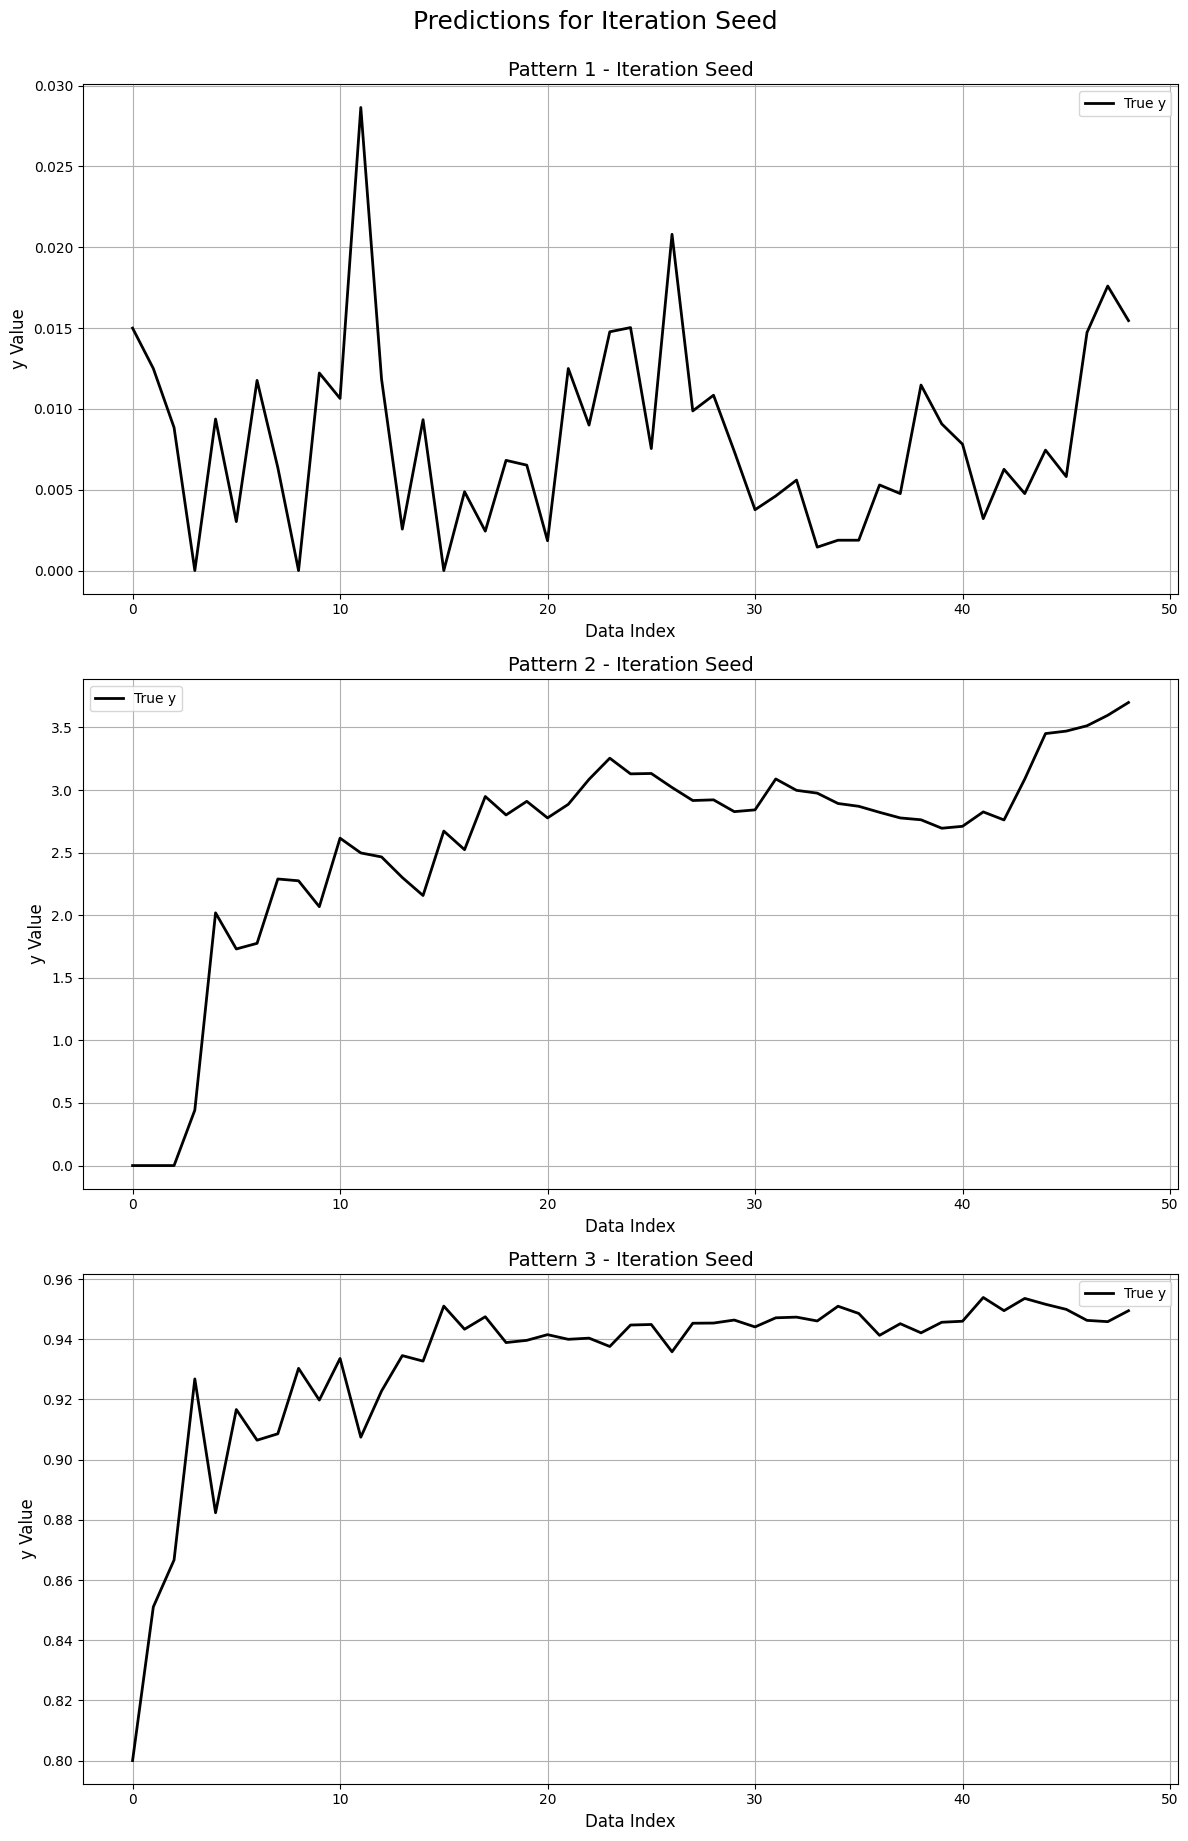

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
x1 = [0.833, 0.8, 0.851, 0.867, 0.927, 0.882, 0.917, 0.906, 0.909, 0.93, 0.92, 0.934, 0.907, 0.923, 0.935, 0.933, 0.951, 0.943, 0.947, 0.939, 0.94, 0.942, 0.94, 0.94, 0.938, 0.945, 0.945, 0.936, 0.945, 0.945, 0.946, 0.944, 0.947, 0.947, 0.946, 0.951, 0.949, 0.941, 0.945, 0.942, 0.946, 0.946, 0.954, 0.95, 0.954, 0.952, 0.95, 0.946, 0.946]
x2 = [0.432, 0.432, 0.576, 1.151, 1.151, 1.151, 1.295, 1.295, 1.439, 1.439, 1.583, 1.583, 1.727, 1.87, 2.014, 2.158, 2.446, 2.59, 2.734, 2.878, 2.878, 3.165, 3.165, 3.453, 3.597, 3.597, 3.597, 3.741, 4.172, 4.316, 4.46, 4.604, 4.748, 4.892, 5.036, 5.036, 5.036, 5.036, 5.323, 5.611, 5.755, 5.899, 5.899, 6.331, 6.474, 6.906, 7.05, 7.05, 7.194]
x3 = [0.0, 0.0, 0.0, 0.0, 0.443, 2.019, 1.73, 1.775, 2.289, 2.275, 2.068, 2.616, 2.498, 2.466, 2.301, 2.157, 2.672, 2.524, 2.948, 2.801, 2.91, 2.777, 2.886, 3.085, 3.254, 3.129, 3.132, 3.02, 2.916, 2.922, 2.827, 2.842, 3.088, 2.998, 2.975, 2.

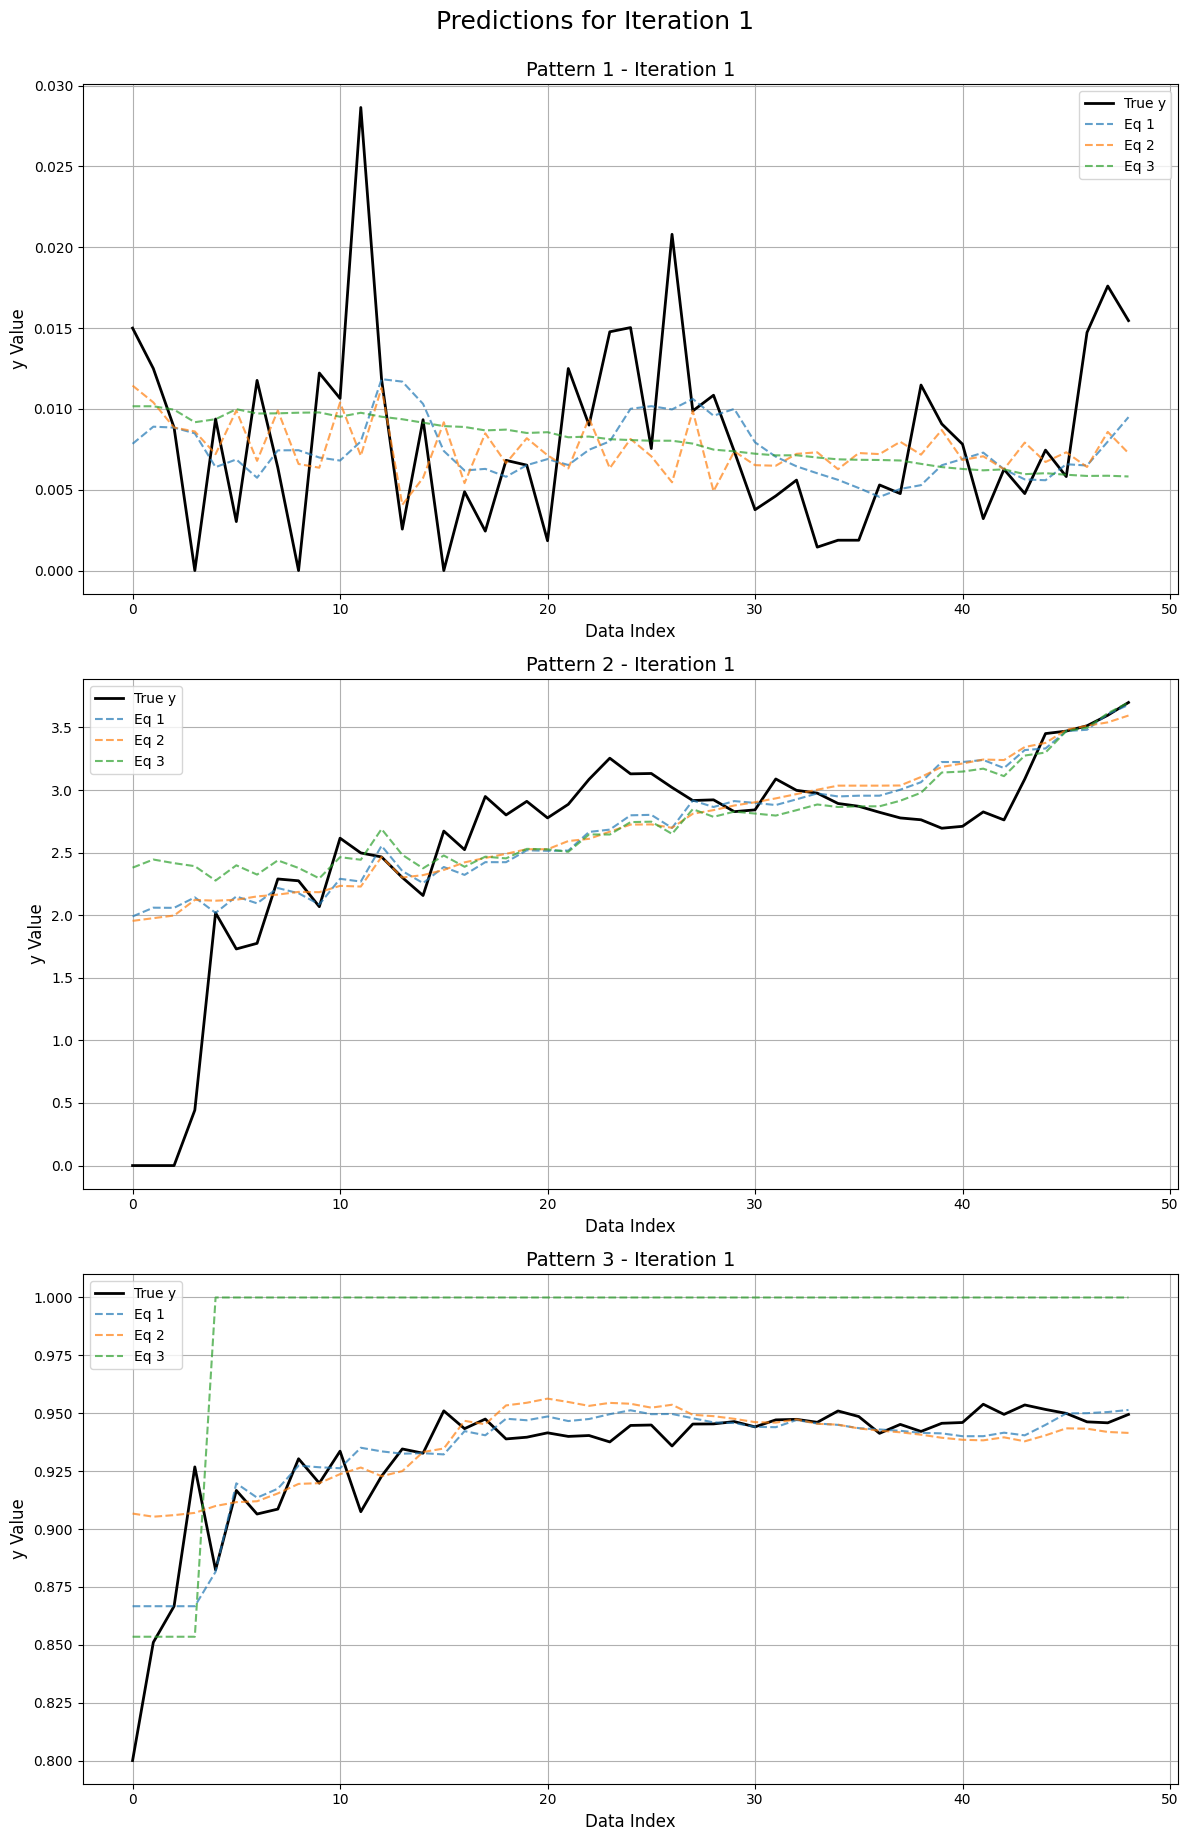

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1*x2+c[2]*x3**2+c[3]*movavg(4, 3)', 'complexity': 17, 'nmae': np.float64(0.14072024320911064), 'fitted_params': [0.00376477584323912, -0.00038536218476132396, 0.00023094433395334782, 0.42159611728903545]}, {'equation': 'c[0]+c[1]*(x4-x5)+c[2]*x1*x3', 'complexity': 13, 'nmae': np.float64(0.14657721647269722), 'fitted_params': [0.009366138138713856, 0.20779750536020825, -0.000793871388181559]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+c[3])', 'complexity': 14, 'nmae': np.float64(0.14962404043753066), 'fitted_params': [0.01824436028972802, 0.00045240000640358404, -0.0058894045831650605, 3.5108795118408347]}], [{'equation': 'c[0]+c[1]*x1/(x2+c[2])+c[3]*x3', 'complexity': 13, 'nmae': np.float64(0.09644292816706627), 'fitted_params': [1.7492461488907718, -5.265807086418364, -29.678670297461245, 13.984930541604296]}, {'equation': 'c[0]+c[1]*x1*x2+c[2]*x3**3', 'complexity': 13, 'nmae': np.float64(0.0991488887930188

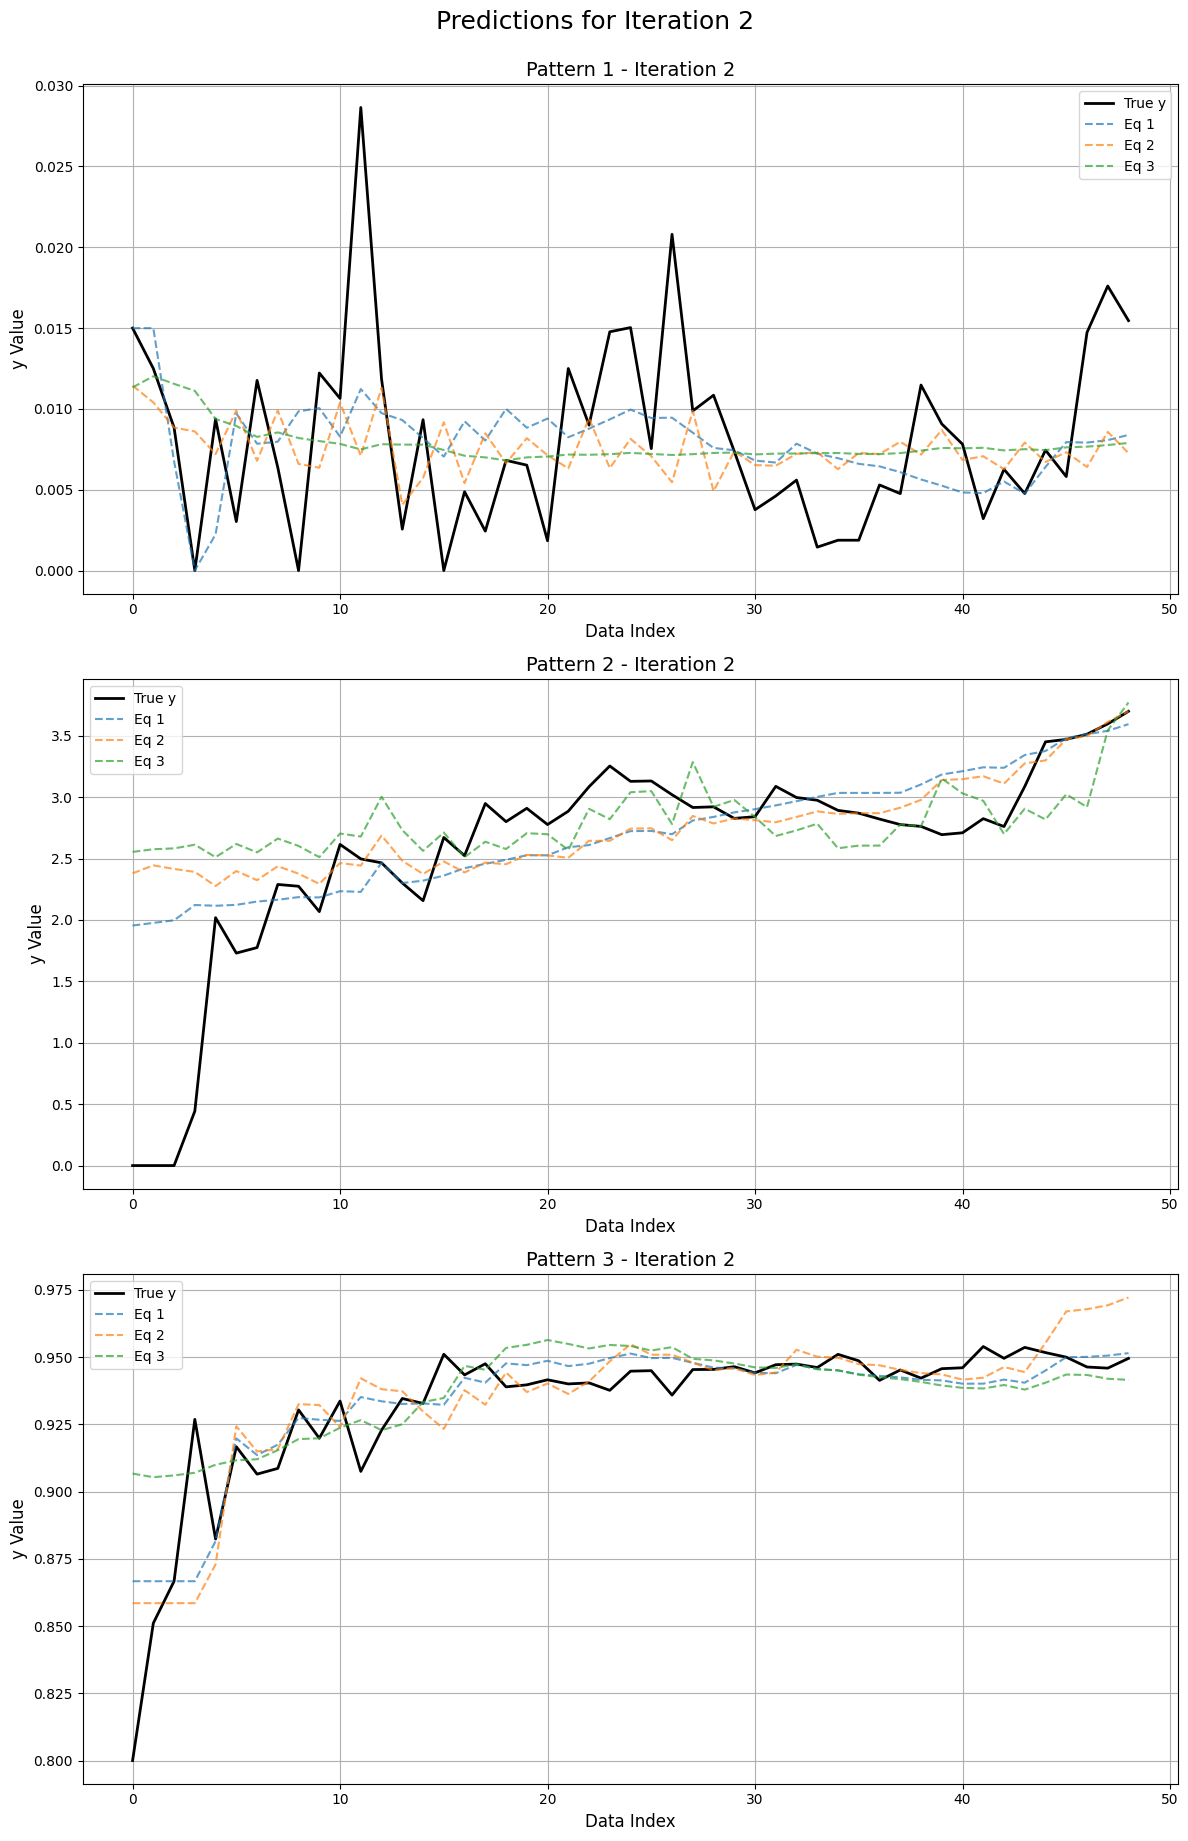

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*movavg(1, 3)+c[2]*x2**2', 'complexity': 11, 'nmae': np.float64(0.14851123494448168), 'fitted_params': [0.04565232709064819, -0.041187752328964204, 2.4405011729890247e-05]}, {'equation': 'c[0]+c[1]*(x4-x5)+c[2]*x1*x3', 'complexity': 13, 'nmae': np.float64(0.14657714440292444), 'fitted_params': [0.009365420160991874, 0.2076543725038693, -0.000792947507048534]}, {'equation': 'c[0]+c[1]*x1*x2+c[2]*x3**2+c[3]*movavg(4, 3)', 'complexity': 17, 'nmae': np.float64(0.14072024320911064), 'fitted_params': [0.00376477584323912, -0.00038536218476132396, 0.00023094433395334782, 0.42159611728903545]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+c[3])', 'complexity': 14, 'nmae': np.float64(0.1393868807123769), 'fitted_params': [-0.0013357771086165528, 0.005457477099816069, -0.004614231021304909, -0.402602484342373]}], [{'equation': 'c[0]+c[1]*x1*x2+c[2]*x3**3', 'complexity': 13, 'nmae': np.float64(0.09914888879301882), 'fitted_

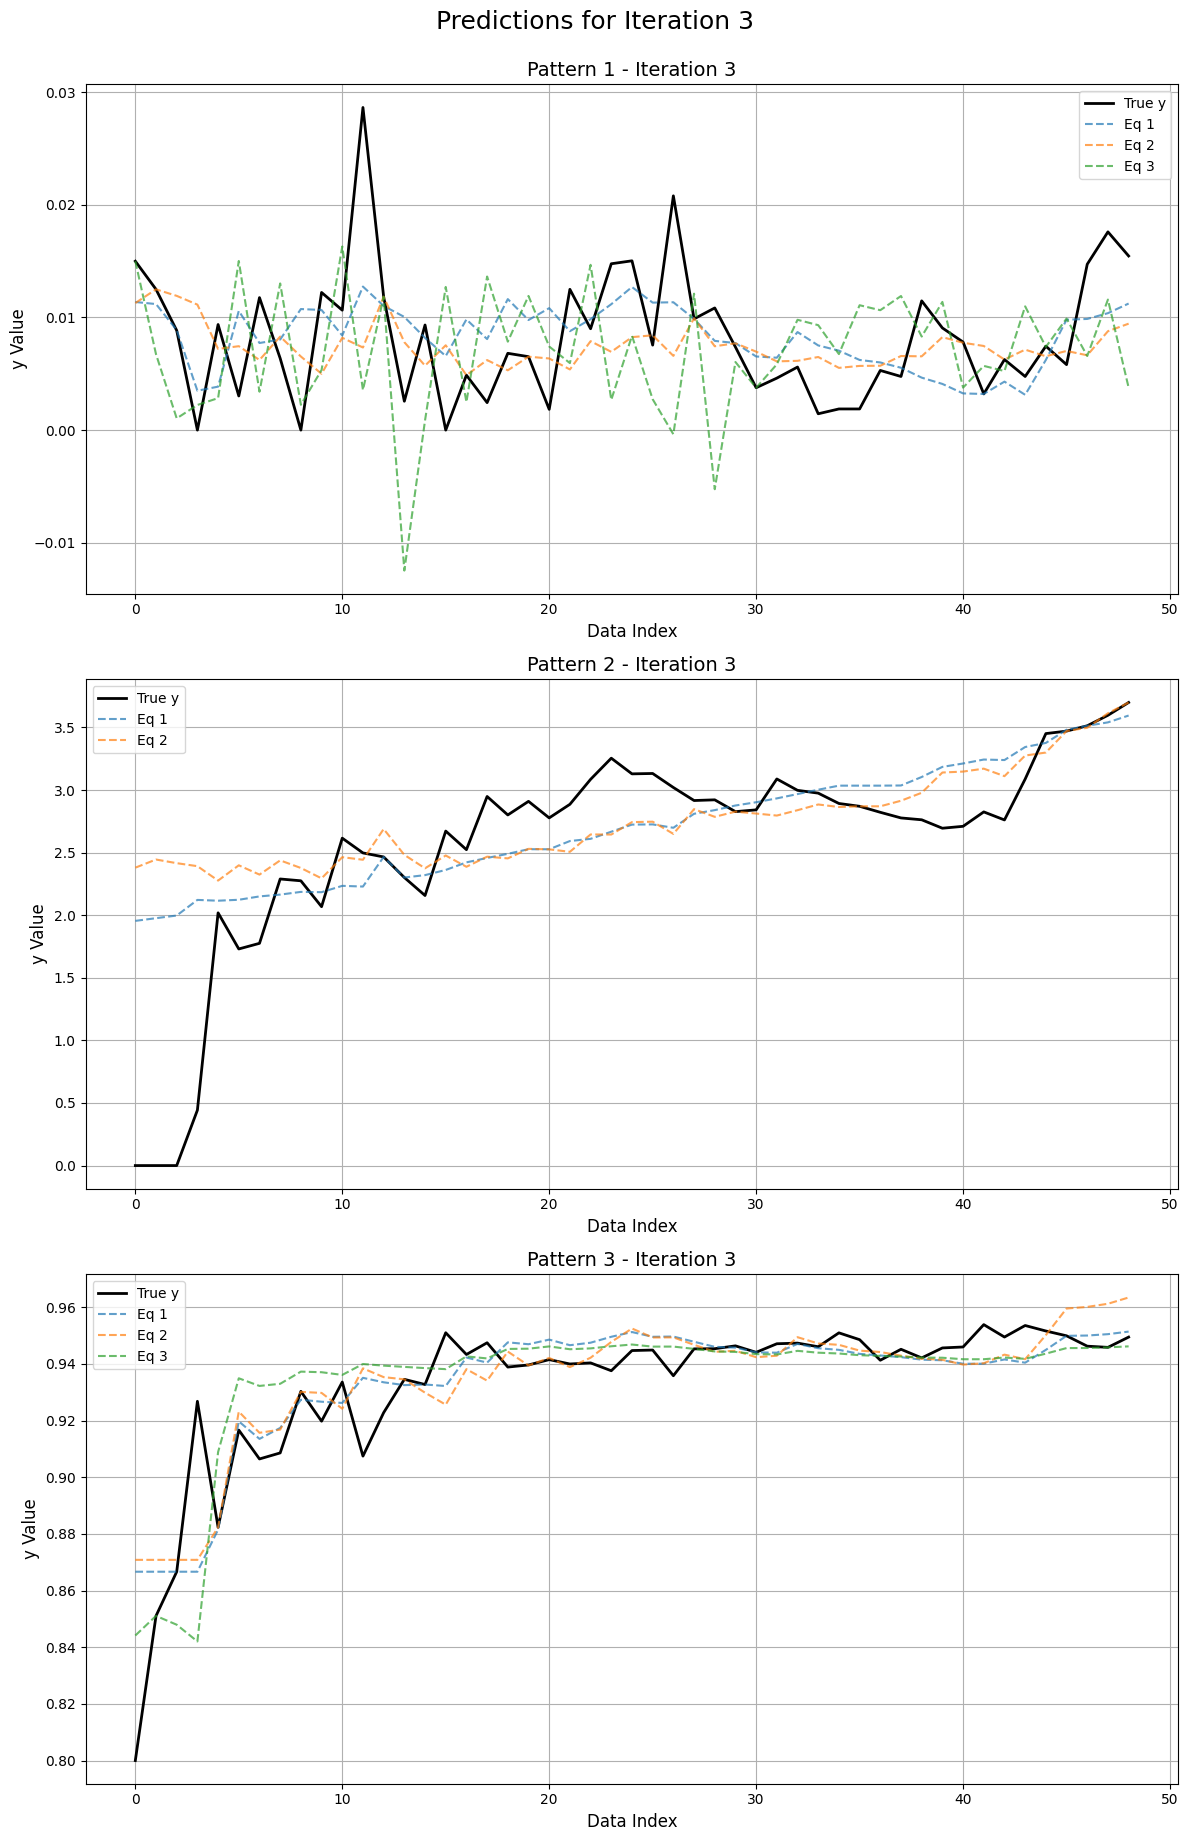

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*movavg(1, 3)+c[2]*x2**2', 'complexity': 11, 'nmae': np.float64(0.14851123494448168), 'fitted_params': [0.04565232709064819, -0.041187752328964204, 2.4405011729890247e-05]}, {'equation': 'c[0]+c[1]*(x4-x5)+c[2]*x1*x3', 'complexity': 13, 'nmae': np.float64(0.14657714440292444), 'fitted_params': [0.009365420160991874, 0.2076543725038693, -0.000792947507048534]}, {'equation': 'c[0]+c[1]*x1*x2+c[2]*(x3)**0.5+c[3]*x4', 'complexity': 17, 'nmae': np.float64(0.13881831675501935), 'fitted_params': [0.008764978894020023, 0.00022005261208809282, -0.002690818870430406, 0.24386296523326056]}, {'equation': 'c[0]+c[1]*log(x2+x5)+c[2]*x3**2', 'complexity': 14, 'nmae': np.float64(0.1386131017537946), 'fitted_params': [0.004700364559223955, -0.00794397576907806, 0.0017178528943652873]}], [{'equation': 'c[0]+c[1]*x1*x2+c[2]*x3**3', 'complexity': 13, 'nmae': np.float64(0.09914888879301882), 'fitted_params': [1.843565269614917, 0.

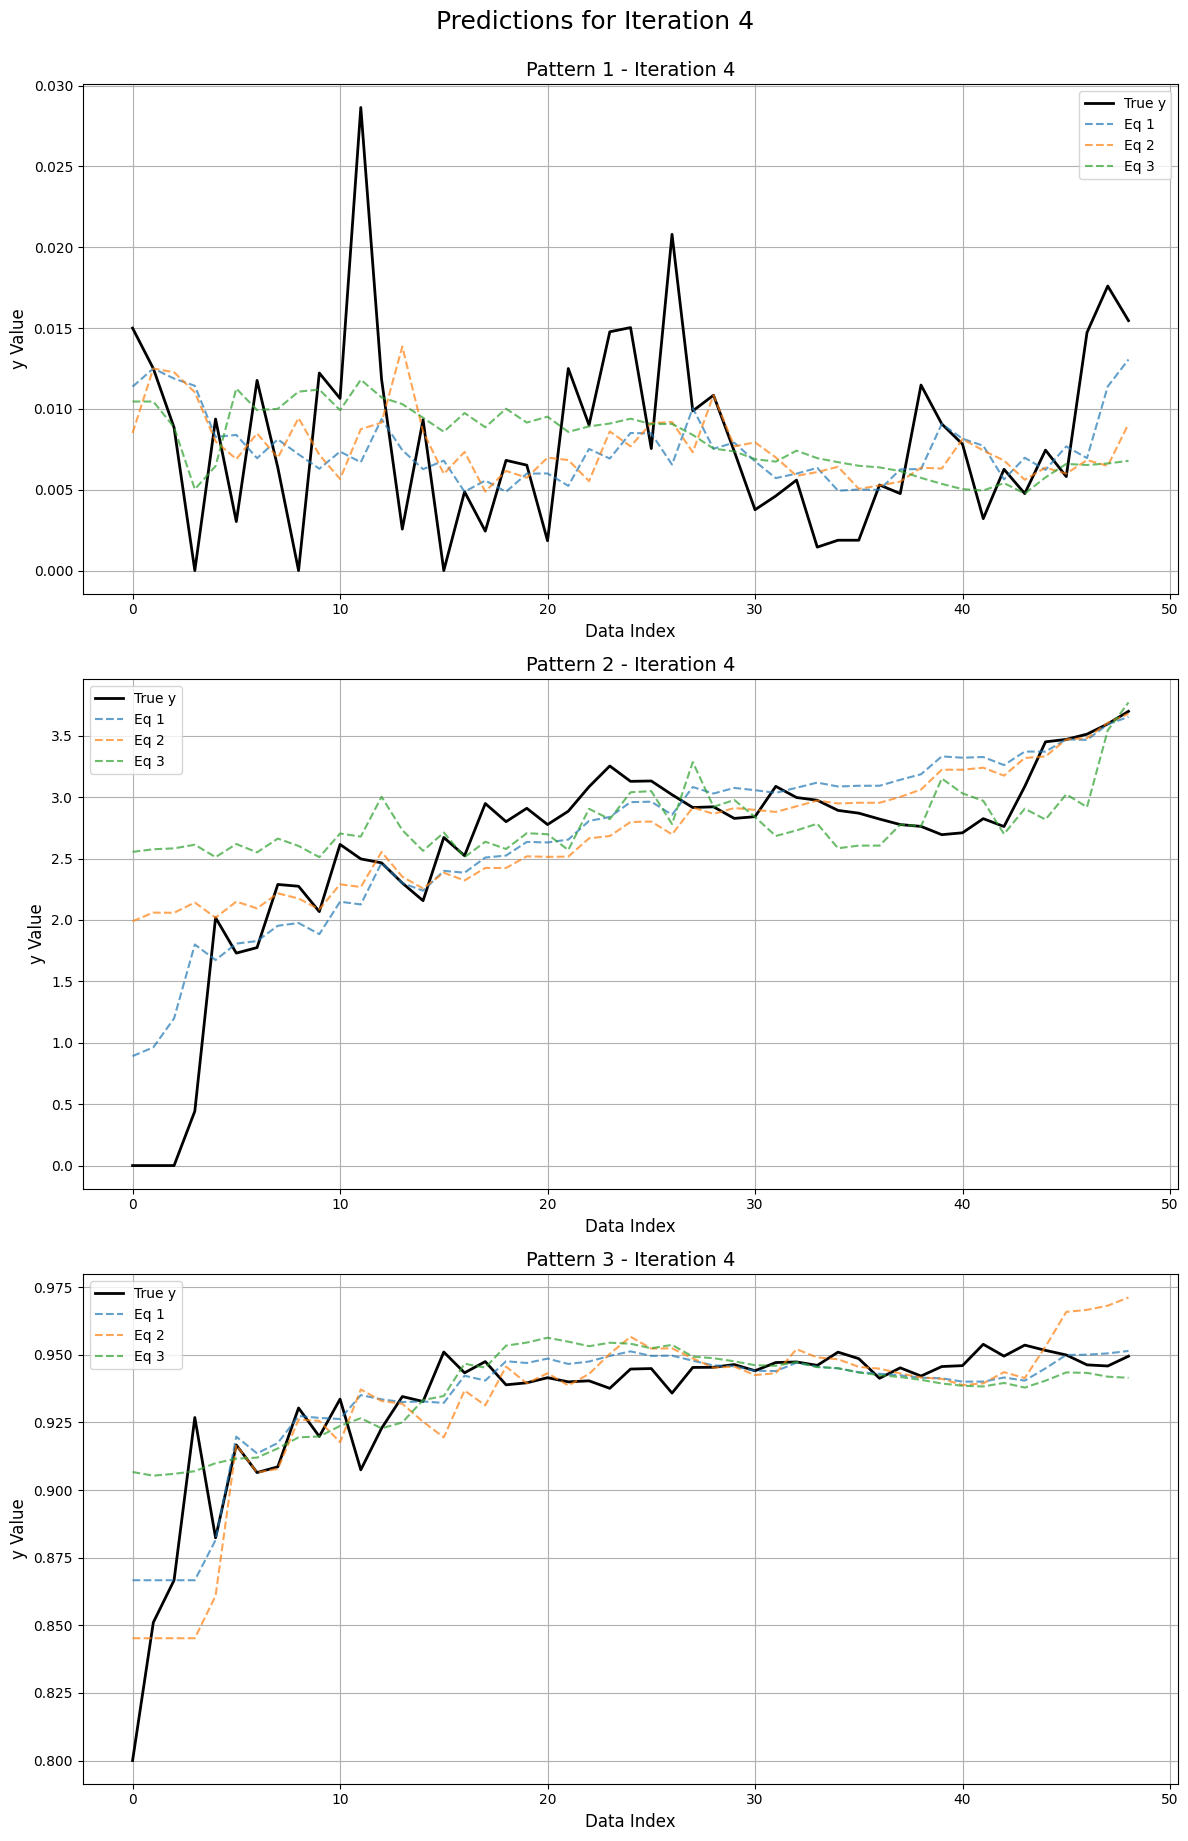

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2)', 'complexity': 12, 'nmae': np.float64(0.14480135591313895), 'fitted_params': [0.005808393049267189, 0.003497189453259068, -0.005534270811973944]}, {'equation': 'c[0]+c[1]*x1/(x2+c[2])+c[3]*x5', 'complexity': 13, 'nmae': np.float64(0.1430225374292691), 'fitted_params': [0.03591976504848427, -3374.144945459945, 102579.01862023649, 0.2894627841892193]}, {'equation': 'c[0]+c[1]*x1*x2+c[2]*(x3)**0.5+c[3]*x4', 'complexity': 17, 'nmae': np.float64(0.13881831675501935), 'fitted_params': [0.008764978894020023, 0.00022005261208809282, -0.002690818870430406, 0.24386296523326056]}, {'equation': 'c[0]+c[1]*log(x2+x5)+c[2]*x3**2', 'complexity': 14, 'nmae': np.float64(0.1386131017537946), 'fitted_params': [0.004700364559223955, -0.00794397576907806, 0.0017178528943652873]}, {'equation': 'c[0]+c[1]*movavg(1, 3)+c[2]*x4*x2', 'complexity': 11, 'nmae': np.float64(0.1342924691331097), 'fitted_params': [0.0598

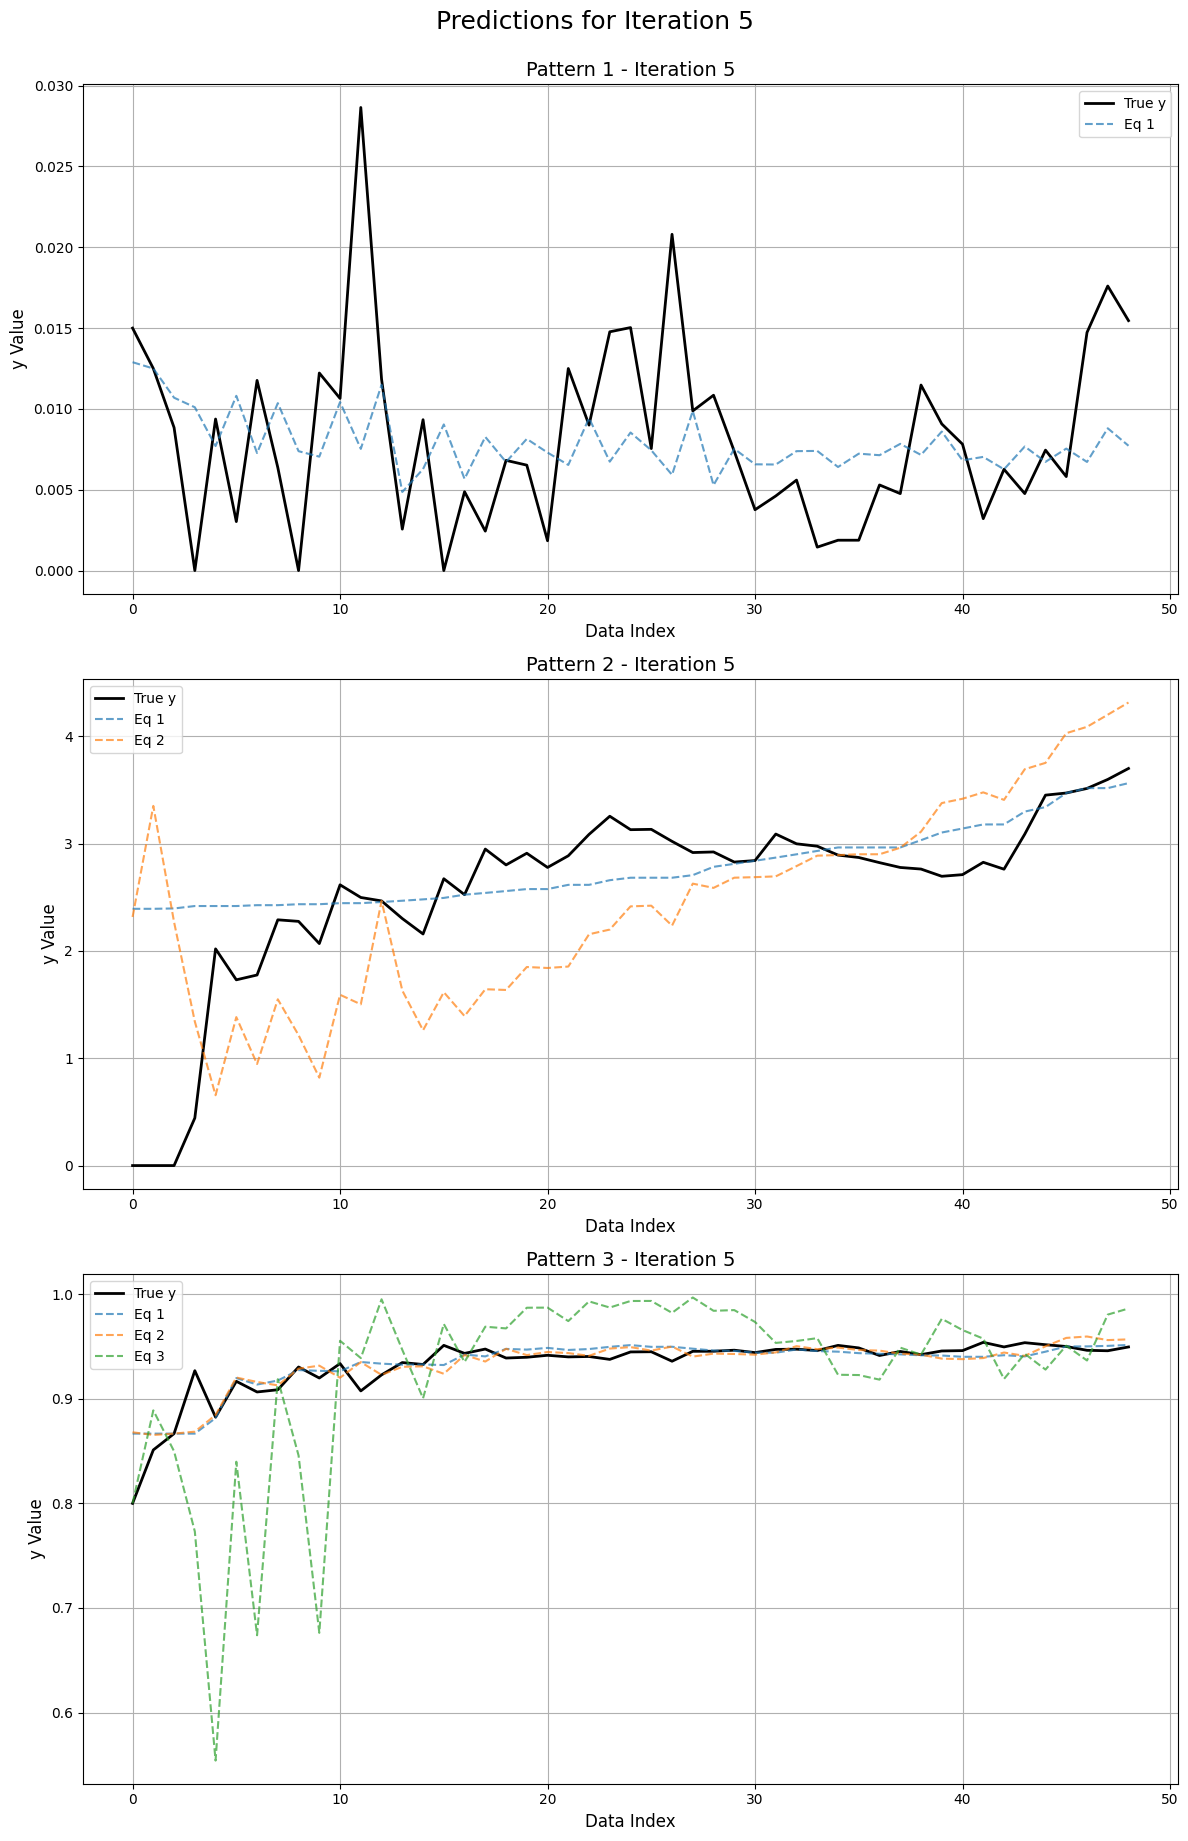

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2)', 'complexity': 12, 'nmae': np.float64(0.14480135591313895), 'fitted_params': [0.005808393049267189, 0.003497189453259068, -0.005534270811973944]}, {'equation': 'c[0]+c[1]*x1/(x2+c[2])+c[3]*x5', 'complexity': 13, 'nmae': np.float64(0.1430225374292691), 'fitted_params': [0.03591976504848427, -3374.144945459945, 102579.01862023649, 0.2894627841892193]}, {'equation': 'c[0]+c[1]*x1*x2+c[2]*(x3)**0.5+c[3]*x4', 'complexity': 17, 'nmae': np.float64(0.13881831675501935), 'fitted_params': [0.008764978894020023, 0.00022005261208809282, -0.002690818870430406, 0.24386296523326056]}, {'equation': 'c[0]+c[1]*log(x2+x5)+c[2]*x3**2', 'complexity': 14, 'nmae': np.float64(0.1386131017537946), 'fitted_params': [0.004700364559223955, -0.00794397576907806, 0.0017178528943652873]}, {'equation': 'c[0]+c[1]*movavg(1, 3)+c[2]*x4*x2', 'complexity': 11, 'nmae': np.float64(0.1342924691331097), 'fitted_params': [0.0598

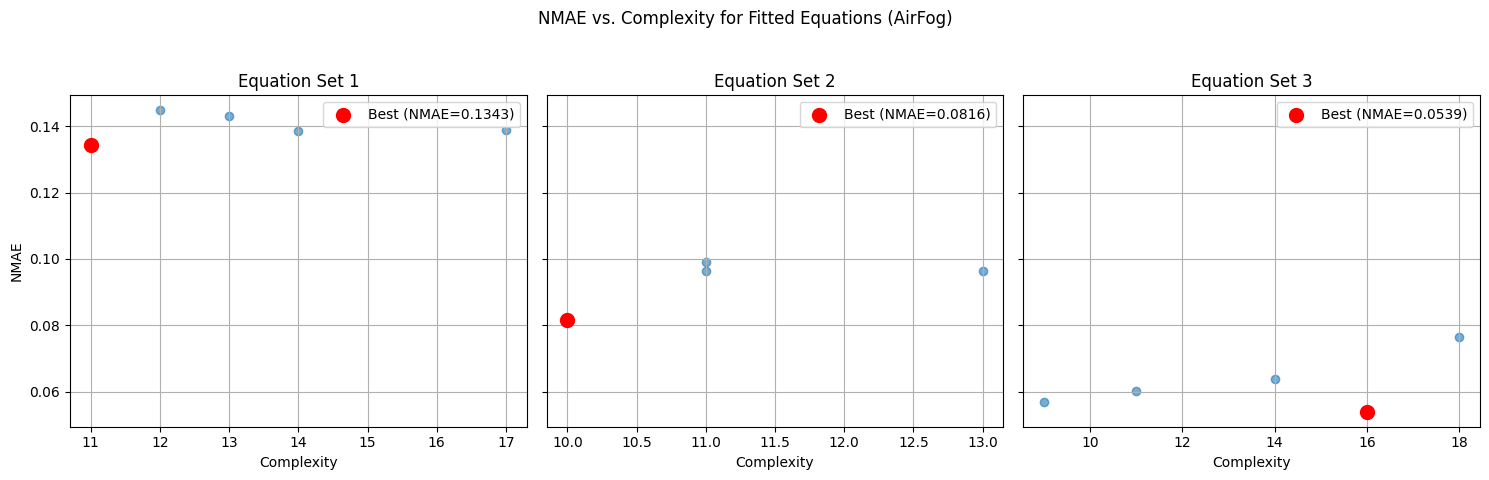

Experiment 1 finished.
Running experiment 2...
Give up equations whose nmae > 0.5: [{'equation': 'movavg(1, 3)+c[0]*x2+c[1]*x3+c[2]*x4+c[3]*(x4-x5)', 'complexity': 19, 'nmae': np.float64(5.598318434636552), 'fitted_params': [0.0031993624968289407, -0.31551532573541, -6.851714285450203, 3.9072604462946465]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*(x2/x5)+c[3]*x3+c[4]*x4', 'complexity': 21, 'nmae': np.float64(inf), 'fitted_params': [1.0, 1.0, 1.0, 1.0, 1.0]}]
Give up equations whose nmae > 0.5: []
Give up equations whose nmae > 0.5: []


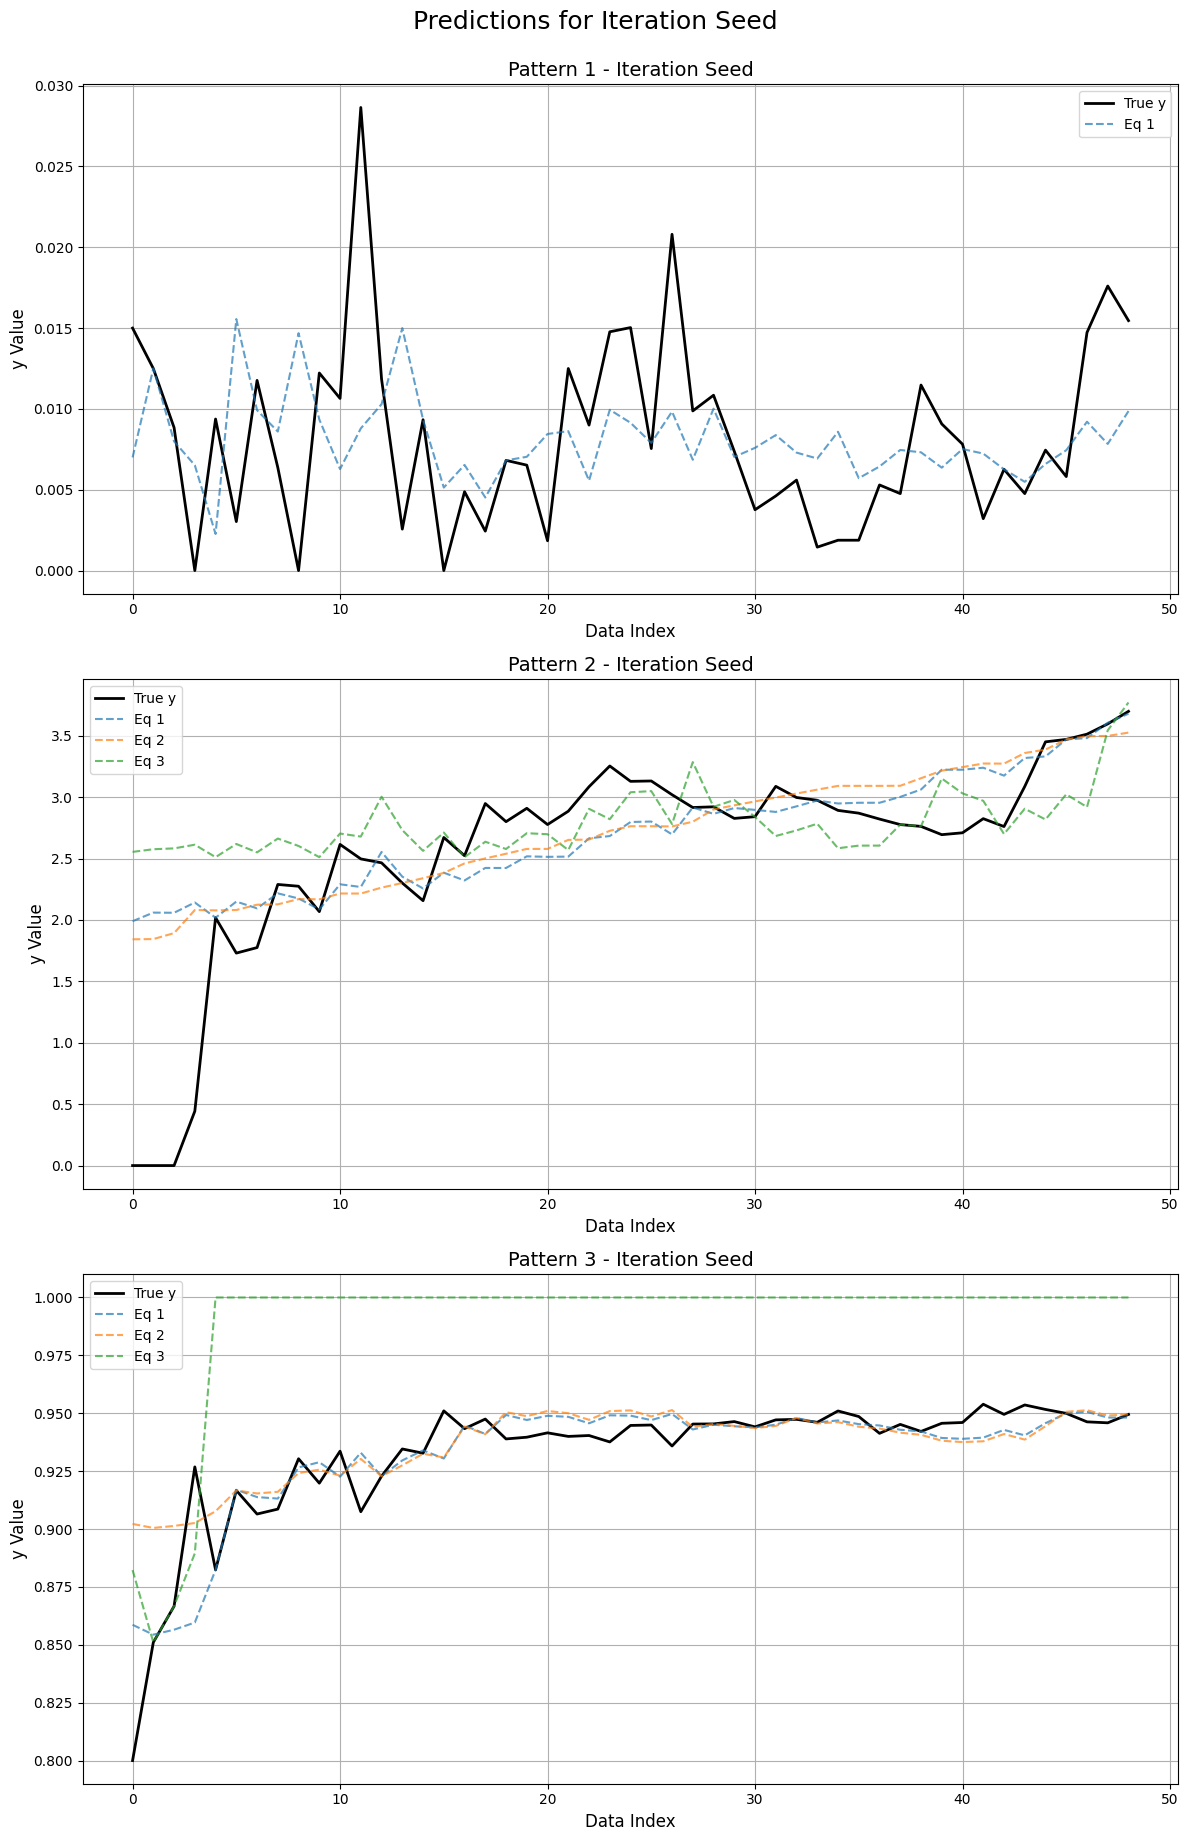

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1 Analysis:
The dataset for Pattern 1 consists of dependent variable y, representing the average compute load at the next time slot. The independent variables include the current task success ratio (x1), current vehicle density (x2), current average V2U density (x3), average compute load at the current time slot (x4), and average compute load at the previous time slot (x5). 

The compute load shows oscillating and delayed behavior, which suggests incorporating polynomial terms, cross-variable interactions, and temporal modeling elements to capture these dynamics. Polynomial terms like x1², x2³ could help in modeling non-linear relationships. Interactions like x1 * x3 or x2 / x5 could capture dependencies between variables. Temporal elements such as moving averages, residual dynamics, and state memory could account for time-dependent behavior. 

Possible expressions include:
1. Polynomial expressions to ca

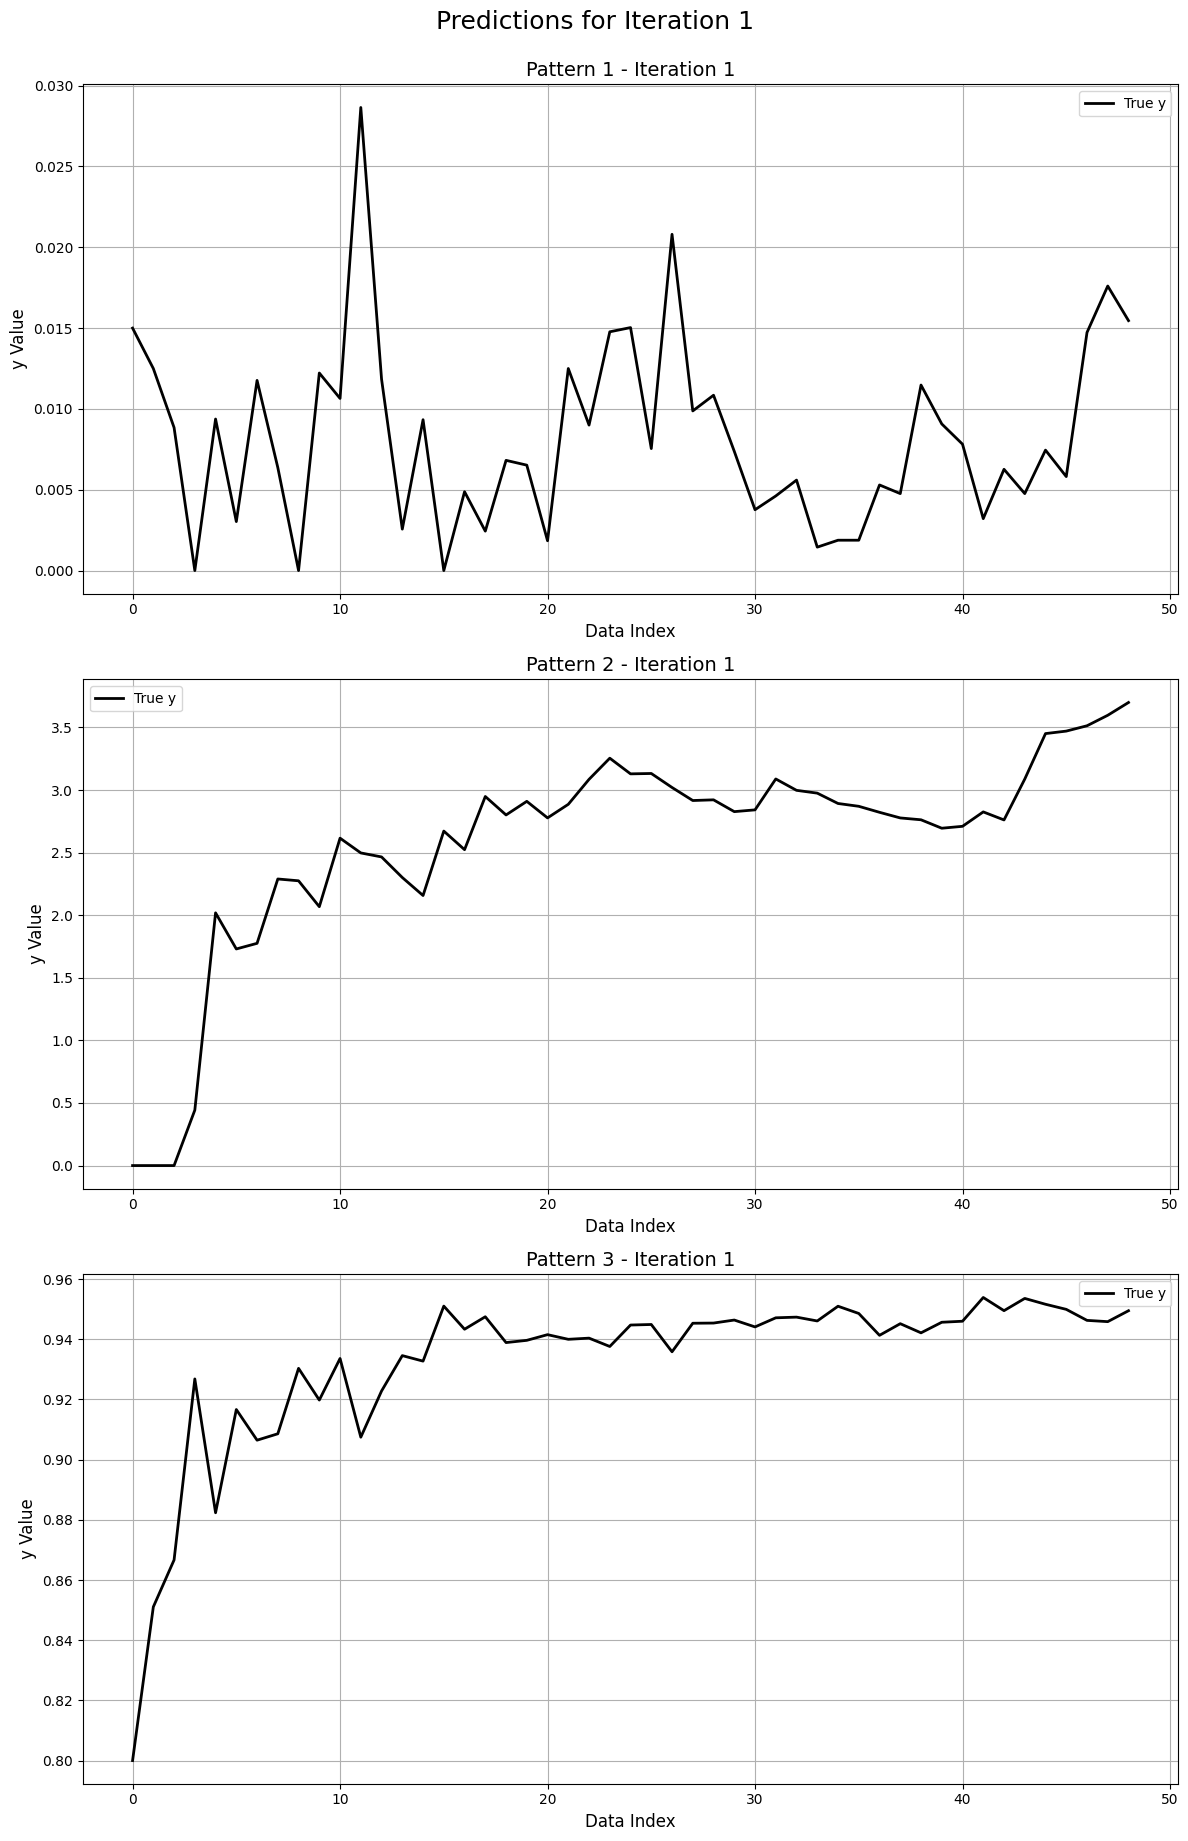

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*(x4-x5)+c[5]*x1*x3', 'complexity': 25, 'nmae': np.float64(0.1487856807996723), 'fitted_params': [0.11514136592739585, -0.1268925485317995, 0.0003603624131429381, 0.05614901287237581, -0.2553883254478049, -0.05557397122507514]}], [{'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*x3', 'complexity': 15, 'nmae': np.float64(0.0964429266045918), 'fitted_params': [-2630.2650388351385, 0.23419314441679628, 50.85980588541986, 13.984921515005148]}, {'equation': 'c[0]+c[1]*log(x1+x2+x3)', 'complexity': 10, 'nmae': np.float64(0.09822522363970985), 'fitted_params': [-3.5477878209545066, 2.651833717100051]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*exp(x2)', 'complexity': 12, 'nmae': np.float64(0.12235447091791332), 'fitted_params': [-1059.66290346262, 9.947775045154316, 0.7979574319277194]}], [{'equation': '1/(1+exp(-(c[0]+c[1]*x1+c[2]*x2+c[3]*x3)))', 'complexity': 20, 'nmae': np.float64(0.05146233373880641), 

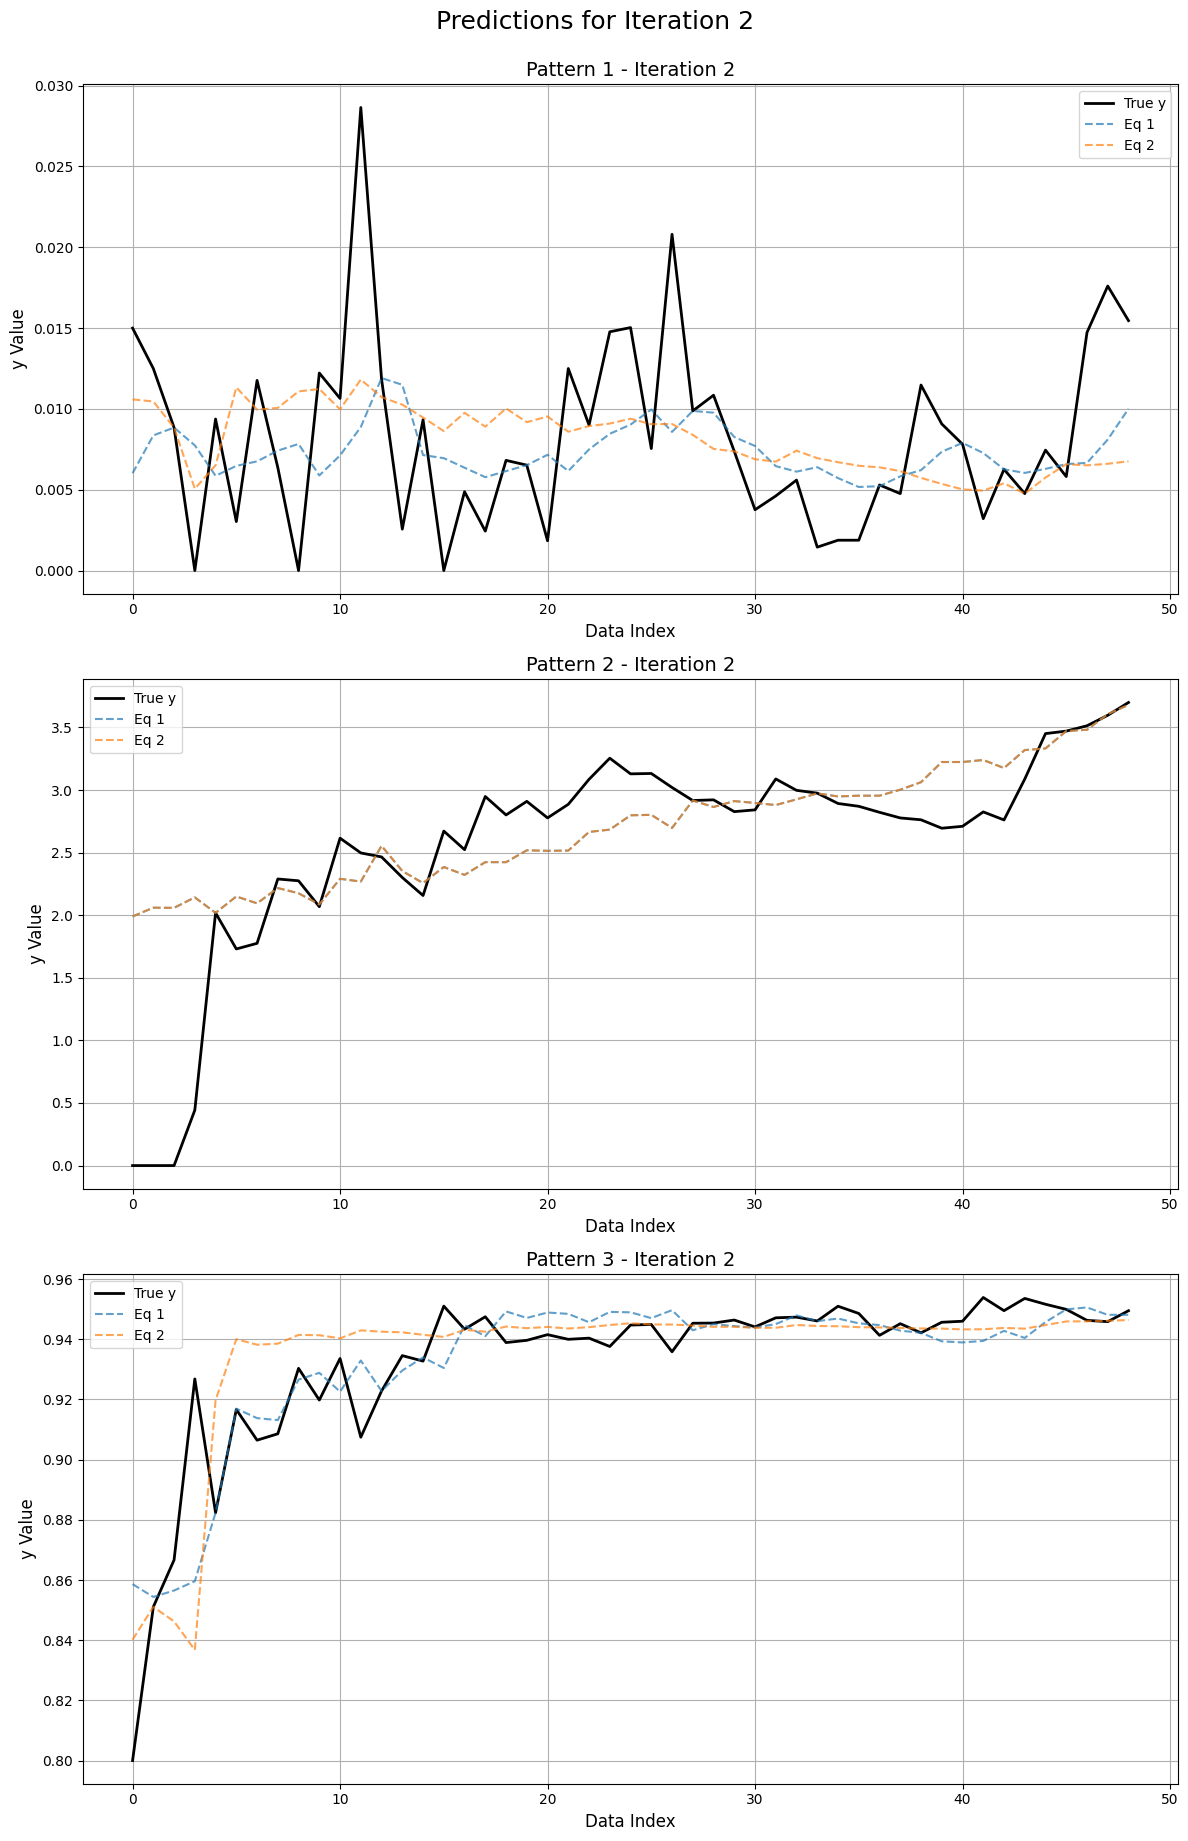

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*(x4-x5)+c[5]*x1*x3', 'complexity': 25, 'nmae': np.float64(0.1487856807996723), 'fitted_params': [0.11514136592739585, -0.1268925485317995, 0.0003603624131429381, 0.05614901287237581, -0.2553883254478049, -0.05557397122507514]}, {'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*x4+c[5]*x5', 'complexity': 21, 'nmae': np.float64(0.1381577026649855), 'fitted_params': [0.0006239187199287439, 0.004269957627986181, -0.0001532280358817875, 0.00023442848559433895, 0.19068055770631412, 0.152871983911604]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+x5)', 'complexity': 14, 'nmae': np.float64(0.14481272259255107), 'fitted_params': [0.005906379784707353, 0.003486023875885701, -0.005573197582802521]}], [{'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*x3', 'complexity': 15, 'nmae': np.float64(0.0964429266045918), 'fitted_params': [-2630.2650388351385, 0.23419314441679628, 50.85980588541986, 13.98492151500514

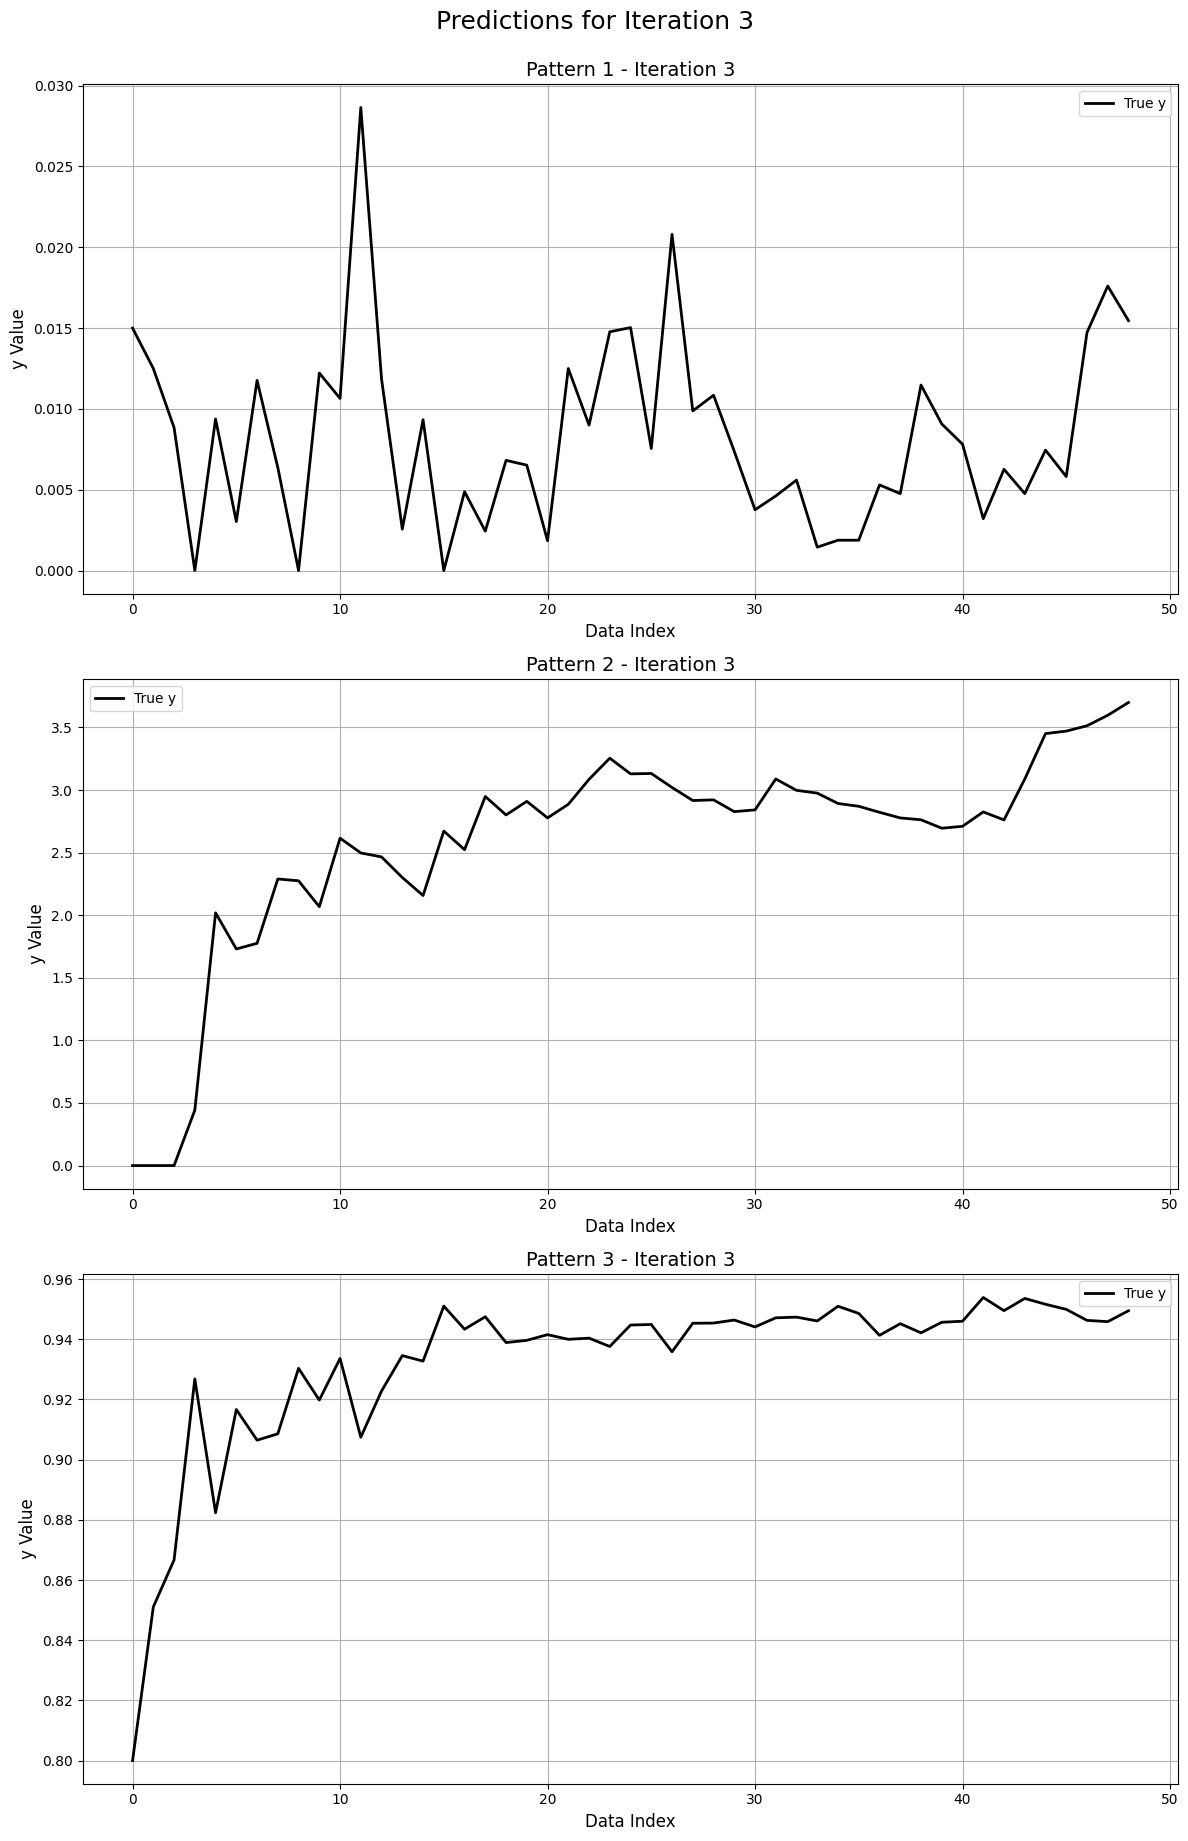

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*(x4-x5)+c[5]*x1*x3', 'complexity': 25, 'nmae': np.float64(0.1487856807996723), 'fitted_params': [0.11514136592739585, -0.1268925485317995, 0.0003603624131429381, 0.05614901287237581, -0.2553883254478049, -0.05557397122507514]}, {'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*x4+c[5]*x5', 'complexity': 21, 'nmae': np.float64(0.1381577026649855), 'fitted_params': [0.0006239187199287439, 0.004269957627986181, -0.0001532280358817875, 0.00023442848559433895, 0.19068055770631412, 0.152871983911604]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+x5)', 'complexity': 14, 'nmae': np.float64(0.14481272259255107), 'fitted_params': [0.005906379784707353, 0.003486023875885701, -0.005573197582802521]}], [{'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*x3', 'complexity': 15, 'nmae': np.float64(0.0964429266045918), 'fitted_params': [-2630.2650388351385, 0.23419314441679628, 50.85980588541986, 13.98492151500514

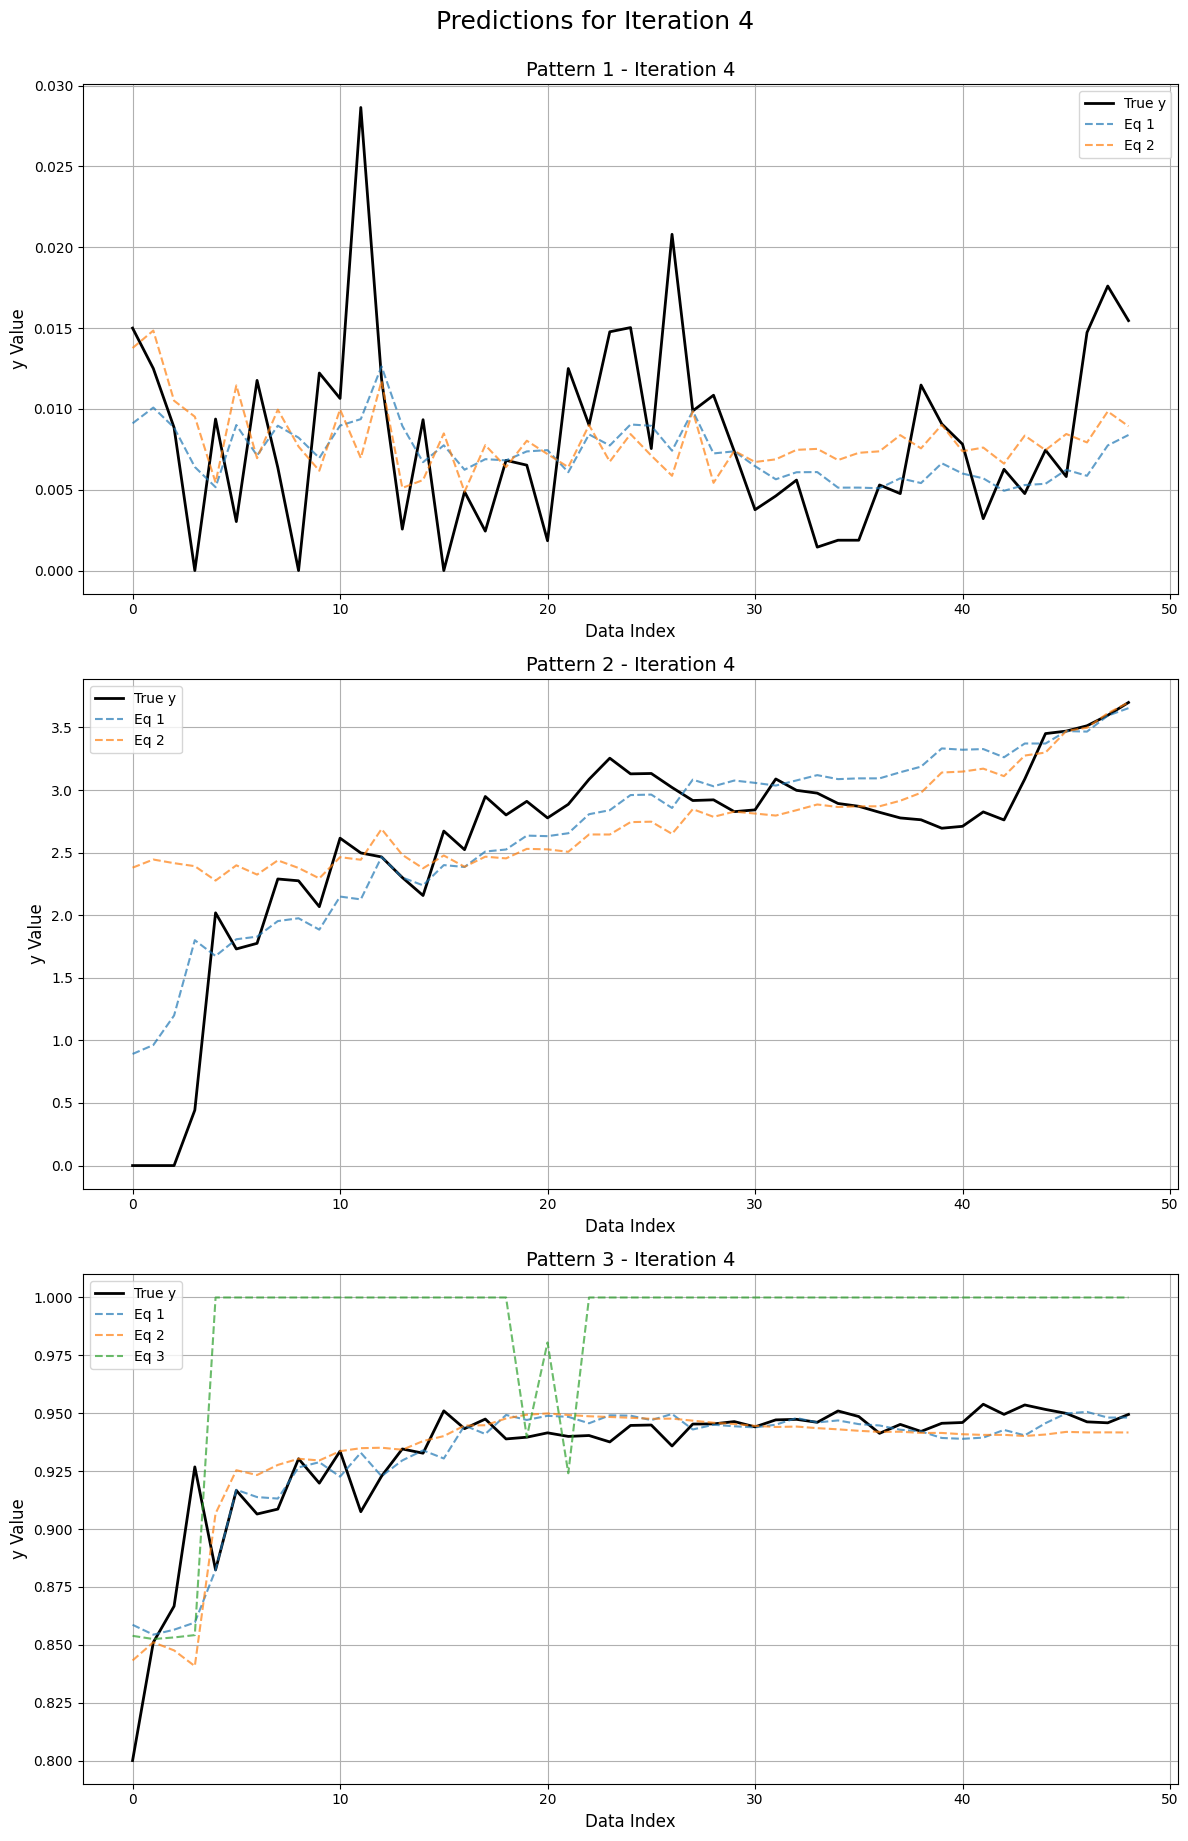

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*(x4-x5)+c[5]*x1*x3', 'complexity': 25, 'nmae': np.float64(0.1487856807996723), 'fitted_params': [0.11514136592739585, -0.1268925485317995, 0.0003603624131429381, 0.05614901287237581, -0.2553883254478049, -0.05557397122507514]}, {'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*x4+c[5]*x5', 'complexity': 21, 'nmae': np.float64(0.1381577026649855), 'fitted_params': [0.0006239187199287439, 0.004269957627986181, -0.0001532280358817875, 0.00023442848559433895, 0.19068055770631412, 0.152871983911604]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+x5)', 'complexity': 14, 'nmae': np.float64(0.14481272259255107), 'fitted_params': [0.005906379784707353, 0.003486023875885701, -0.005573197582802521]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+x5)+c[3]*x4', 'complexity': 18, 'nmae': np.float64(0.1384191107335812), 'fitted_params': [0.0049597550264516635, 0.0013797930747916096, -0.0024805143167015305, 0.

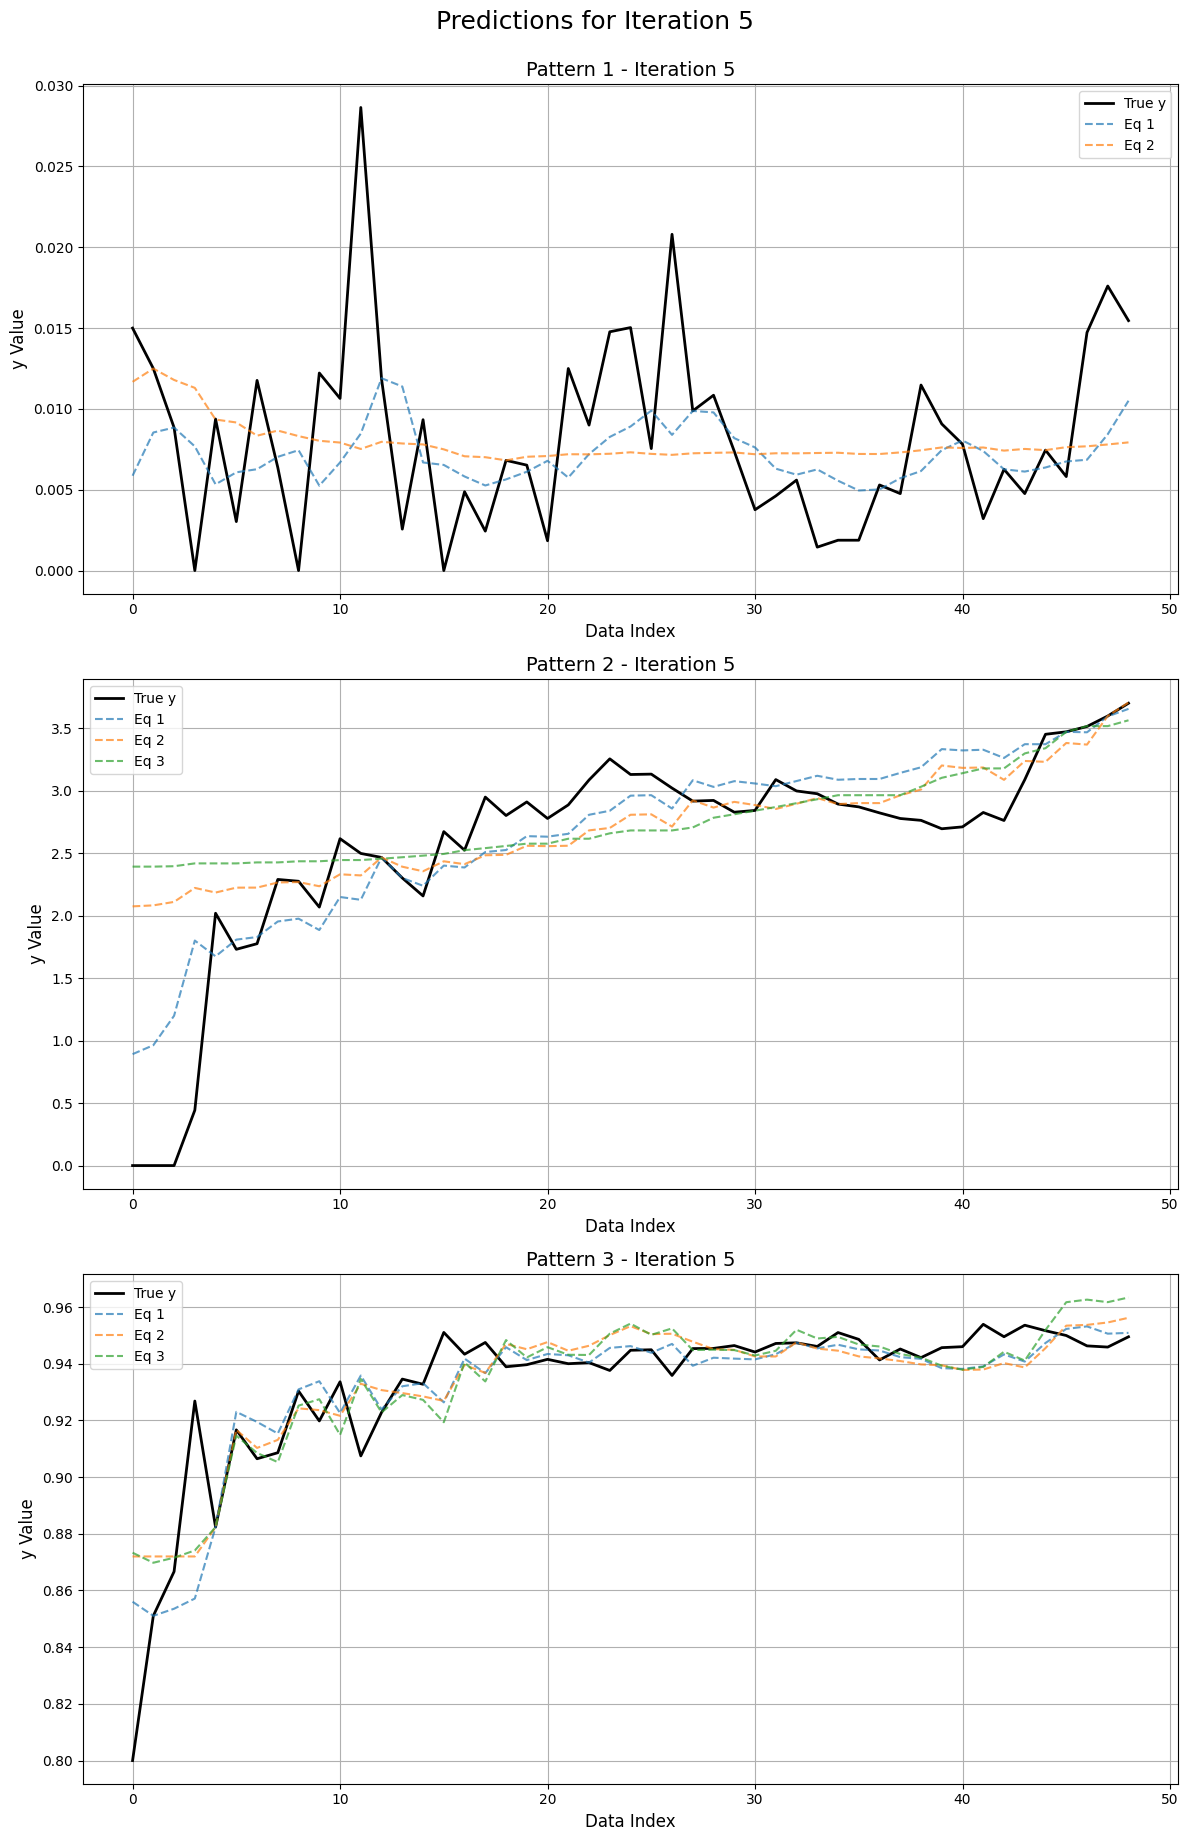

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+c[1]*x1+c[2]*x2+c[3]*x3+c[4]*(x4-x5)+c[5]*x1*x3', 'complexity': 25, 'nmae': np.float64(0.1487856807996723), 'fitted_params': [0.11514136592739585, -0.1268925485317995, 0.0003603624131429381, 0.05614901287237581, -0.2553883254478049, -0.05557397122507514]}, {'equation': 'c[0]+c[1]*x1+c[2]*x2**2+c[3]*movavg(1, 3)', 'complexity': 15, 'nmae': np.float64(0.14827660507617788), 'fitted_params': [0.04850387560001951, -0.005071362759515488, 2.496594871154761e-05, -0.03912845333840569]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+x5)', 'complexity': 14, 'nmae': np.float64(0.14481272259255107), 'fitted_params': [0.005906379784707353, 0.003486023875885701, -0.005573197582802521]}, {'equation': 'c[0]+c[1]*x1*x3+c[2]*log(x2+x5)+c[3]*x4', 'complexity': 18, 'nmae': np.float64(0.1384191107335812), 'fitted_params': [0.0049597550264516635, 0.0013797930747916096, -0.0024805143167015305, 0.2064196330216299]}, {'equation': 'c[0]+c[1]*x1

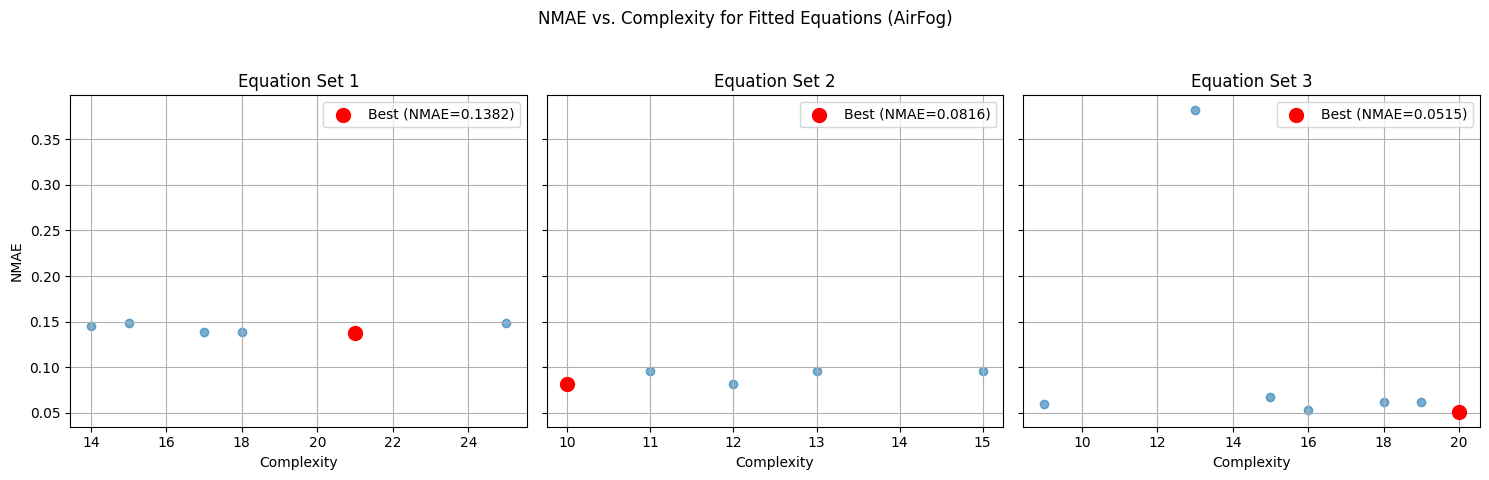

Experiment 2 finished.
Running experiment 3...
Give up equations whose nmae > 0.5: [{'equation': 'movavg(1, 3)+x5-x4', 'complexity': 5, 'nmae': np.float64(32.077792285612446), 'fitted_params': []}, {'equation': 'x1*x2+x3*x4', 'complexity': 7, 'nmae': np.float64(118.47980718218722), 'fitted_params': []}, {'equation': 'x1*x3+log(x5)', 'complexity': 6, 'nmae': np.float64(inf), 'fitted_params': []}]
Give up equations whose nmae > 0.5: [{'equation': 'x2*x3*x1', 'complexity': 5, 'nmae': np.float64(0.6429994709699072), 'fitted_params': []}, {'equation': 'x1*x3+x2', 'complexity': 5, 'nmae': np.float64(1.2555906663912442), 'fitted_params': []}]
Give up equations whose nmae > 0.5: [{'equation': '1/(1+exp(-x1*x2))', 'complexity': 10, 'nmae': np.float64(0.604000087978572), 'fitted_params': []}, {'equation': 'min(1,max(0,x1+x2-x3))', 'complexity': 5, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': 'x1/(x2+x3)', 'complexity': 5, 'nmae': np.float64(4.535043311848259), 'fitt

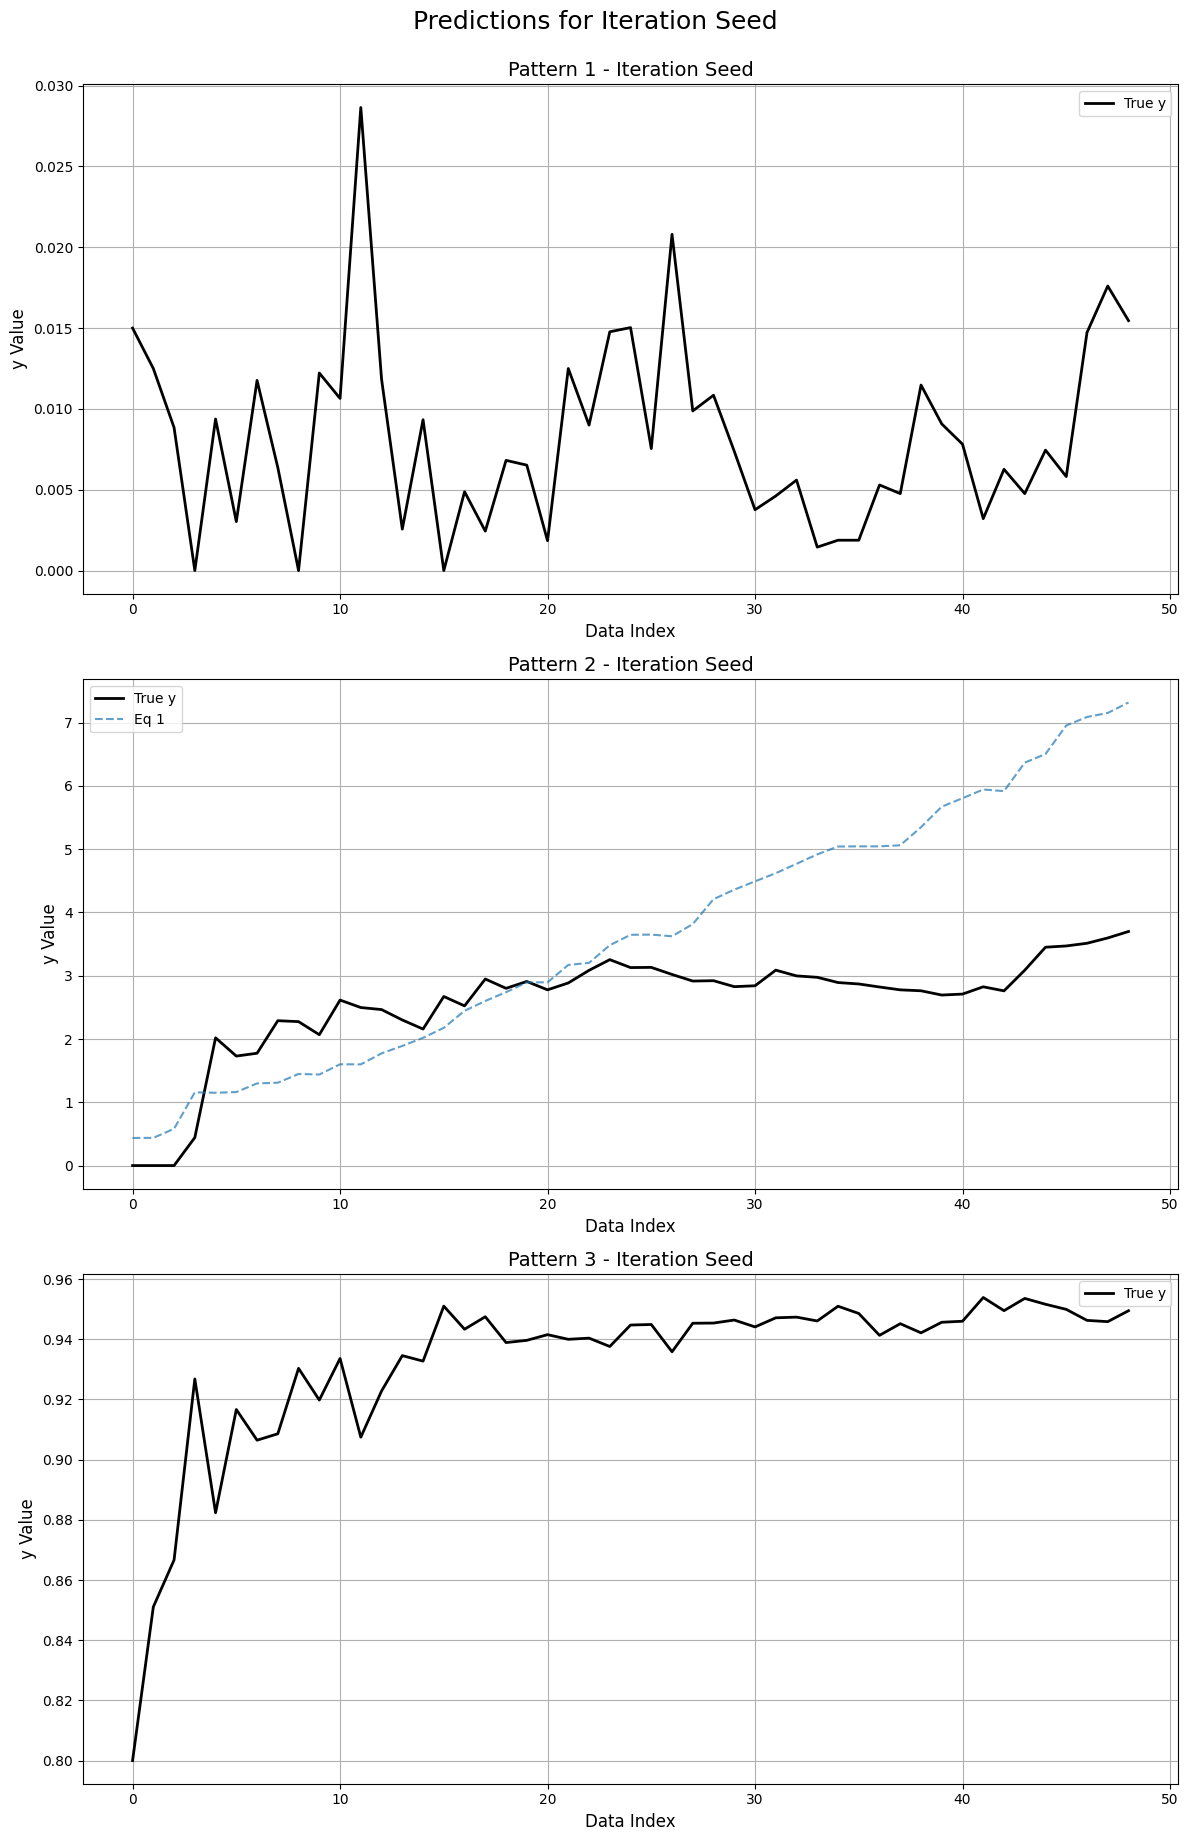

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1 involves predicting the average compute load at the next time slot based on multiple independent variables. The average compute load shows complex oscillating and delayed behavior due to task arrival rates, CPU capacities, and traffic congestion, so we expect polynomial terms and interactions to be useful. The moving average and residual dynamics can help capture temporal effects. We will explore polynomial terms, exponential and logarithmic transformations, cross-variable interactions, and temporal modeling elements.

Pattern 2 predicts the average V2U rate based on current vehicle density, UAV density, and compute load. The V2U rate is influenced by spatial constraints and link availability, which means interactions between variables might be significant. Polynomial terms can capture non-linear effects, while exponential and logarithmic transformations might capture growth patterns.

Pattern 3 involve

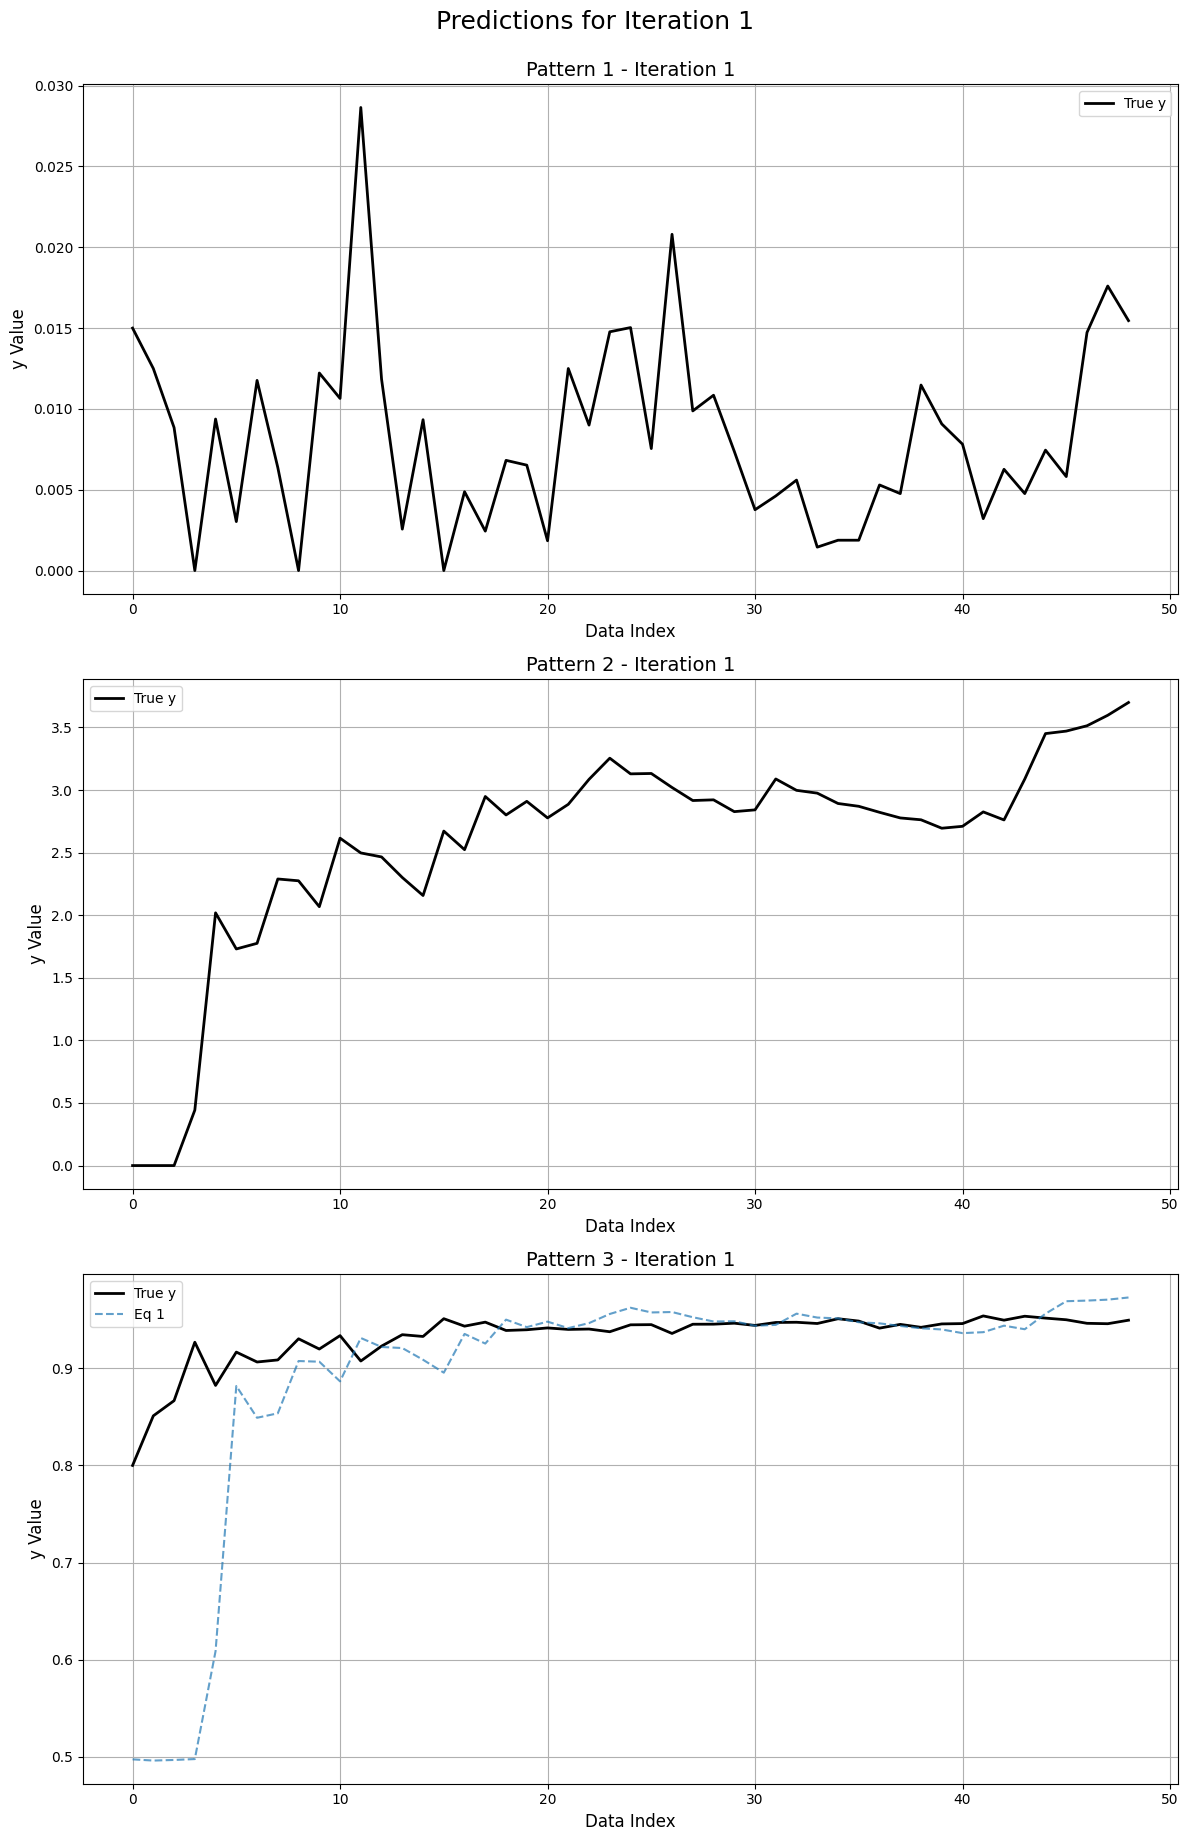

Iteration:1
SciPy feedback used for this iteration:
[[], [{'equation': 'x1+movavg(1, 3)*x3', 'complexity': 5, 'nmae': np.float64(0.375202524848738), 'fitted_params': []}], [{'equation': '1/(1+exp(-(x1-x3)))', 'complexity': 10, 'nmae': np.float64(0.3171038758771126), 'fitted_params': []}]]
LLM thoughts:
For the first pattern, the dependent variable is the average compute load for the next time slot. Key observations from the dataset and context for pattern 1 include:

1. **Compute Load Dynamics**: The compute load shows oscillating and delayed behavior, influenced by complex interactions between task arrival rates, CPU capacities, and traffic congestion.
2. **Polynomial and Cross-Variable Interactions**: Polynomial terms such as x1² and x2³, as well as cross-variable interactions like x1 * x3, can capture non-linear relationships.
3. **Temporal Modeling**: Elements like moving averages and residual dynamics (e.g., x1 - x2) can be used to model temporal changes.

**Candidate Equations**:

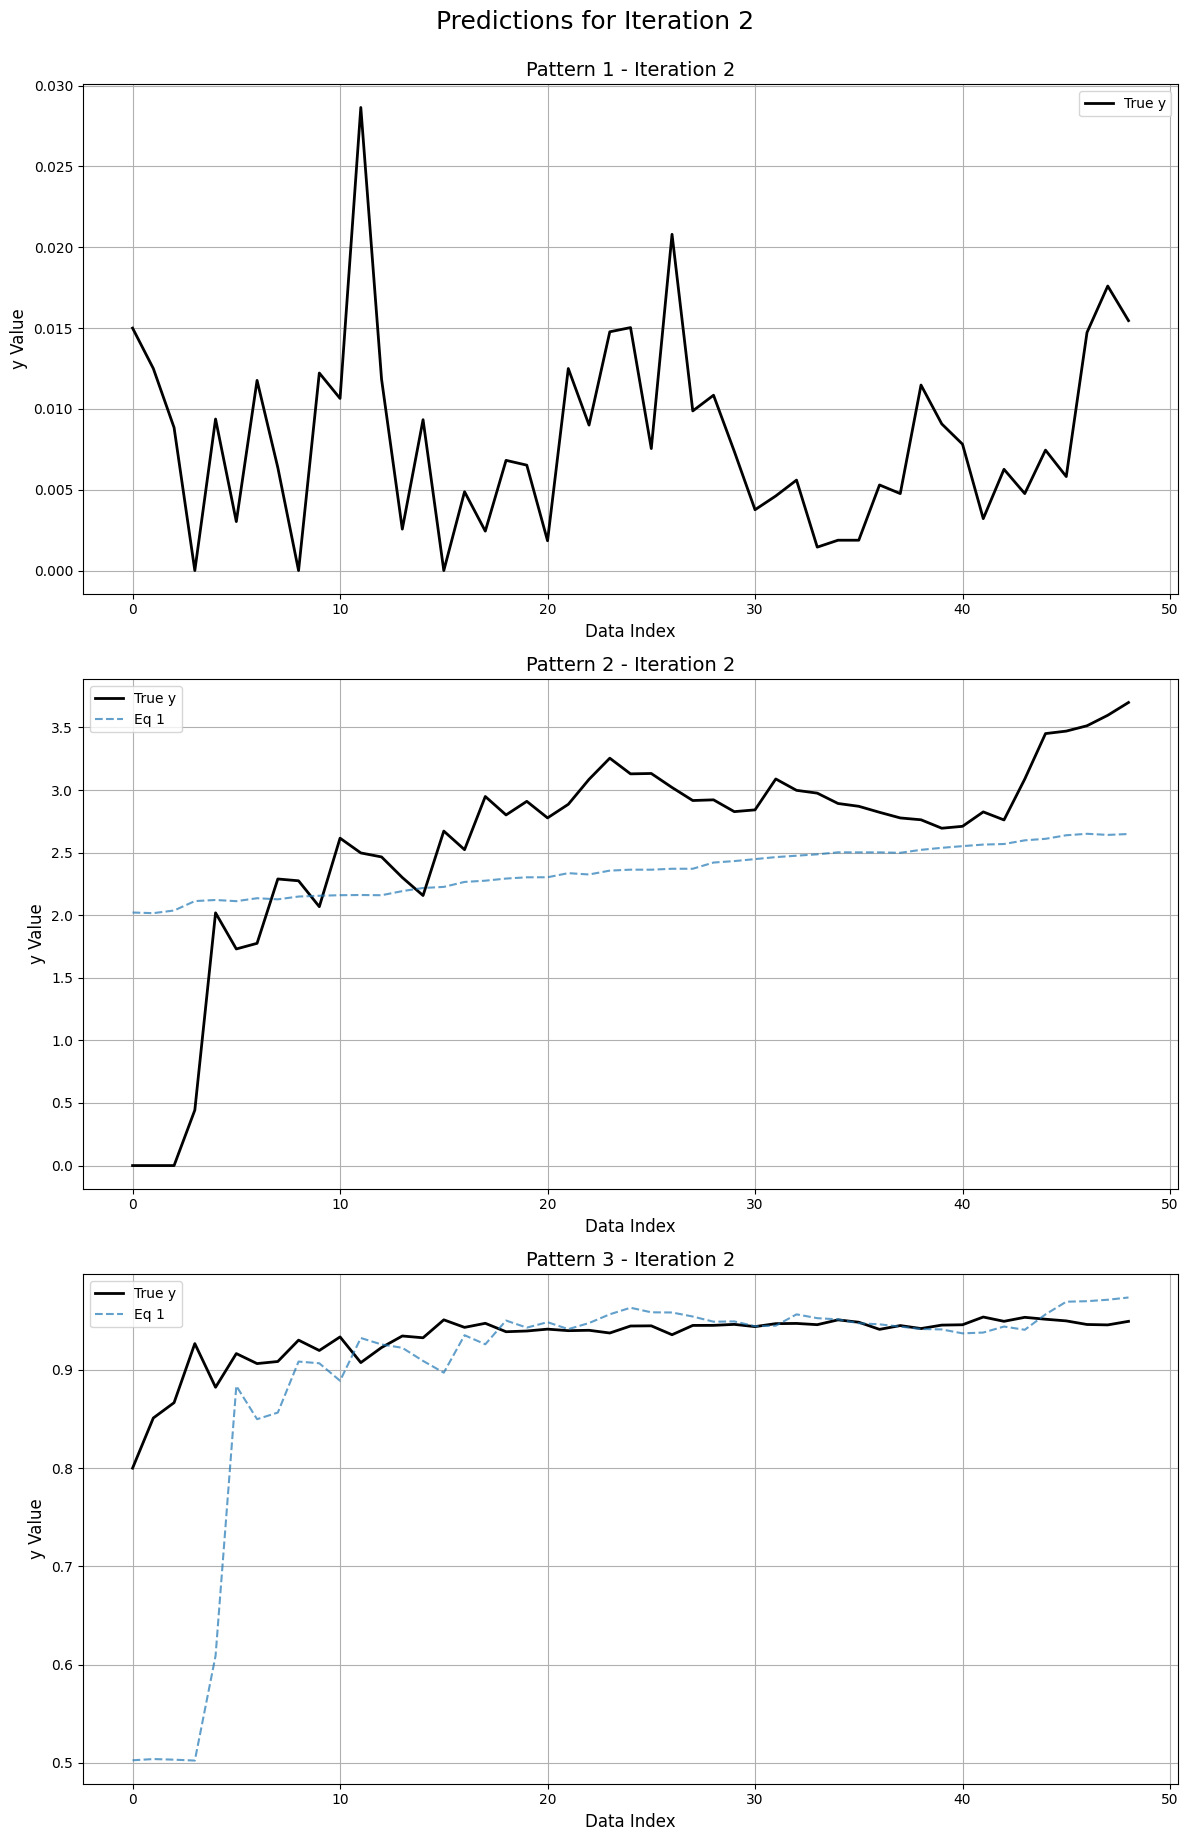

Iteration:2
SciPy feedback used for this iteration:
[[], [{'equation': 'x1+movavg(1, 3)*x3', 'complexity': 5, 'nmae': np.float64(0.375202524848738), 'fitted_params': []}, {'equation': 'log(x1+x2)-x3', 'complexity': 6, 'nmae': np.float64(0.1569790562612386), 'fitted_params': []}], [{'equation': '1/(1+exp(-(x1-x3)))', 'complexity': 10, 'nmae': np.float64(0.3171038758771126), 'fitted_params': []}, {'equation': '1/(1+exp(-(x1+x3)))', 'complexity': 10, 'nmae': np.float64(0.3138574287120163), 'fitted_params': []}]]
LLM thoughts:
Pattern 1:
- The dependent variable is the average compute load at the next time slot. The independent variables include task success ratio, vehicle density, V2U density, and compute load at the current and previous time slots.
- Observing the given datasets, the compute load shows oscillating and delayed behavior, possibly due to traffic congestion and task arrival rates.
- Moving averages and residual dynamics could be beneficial, as the data involves temporal elem

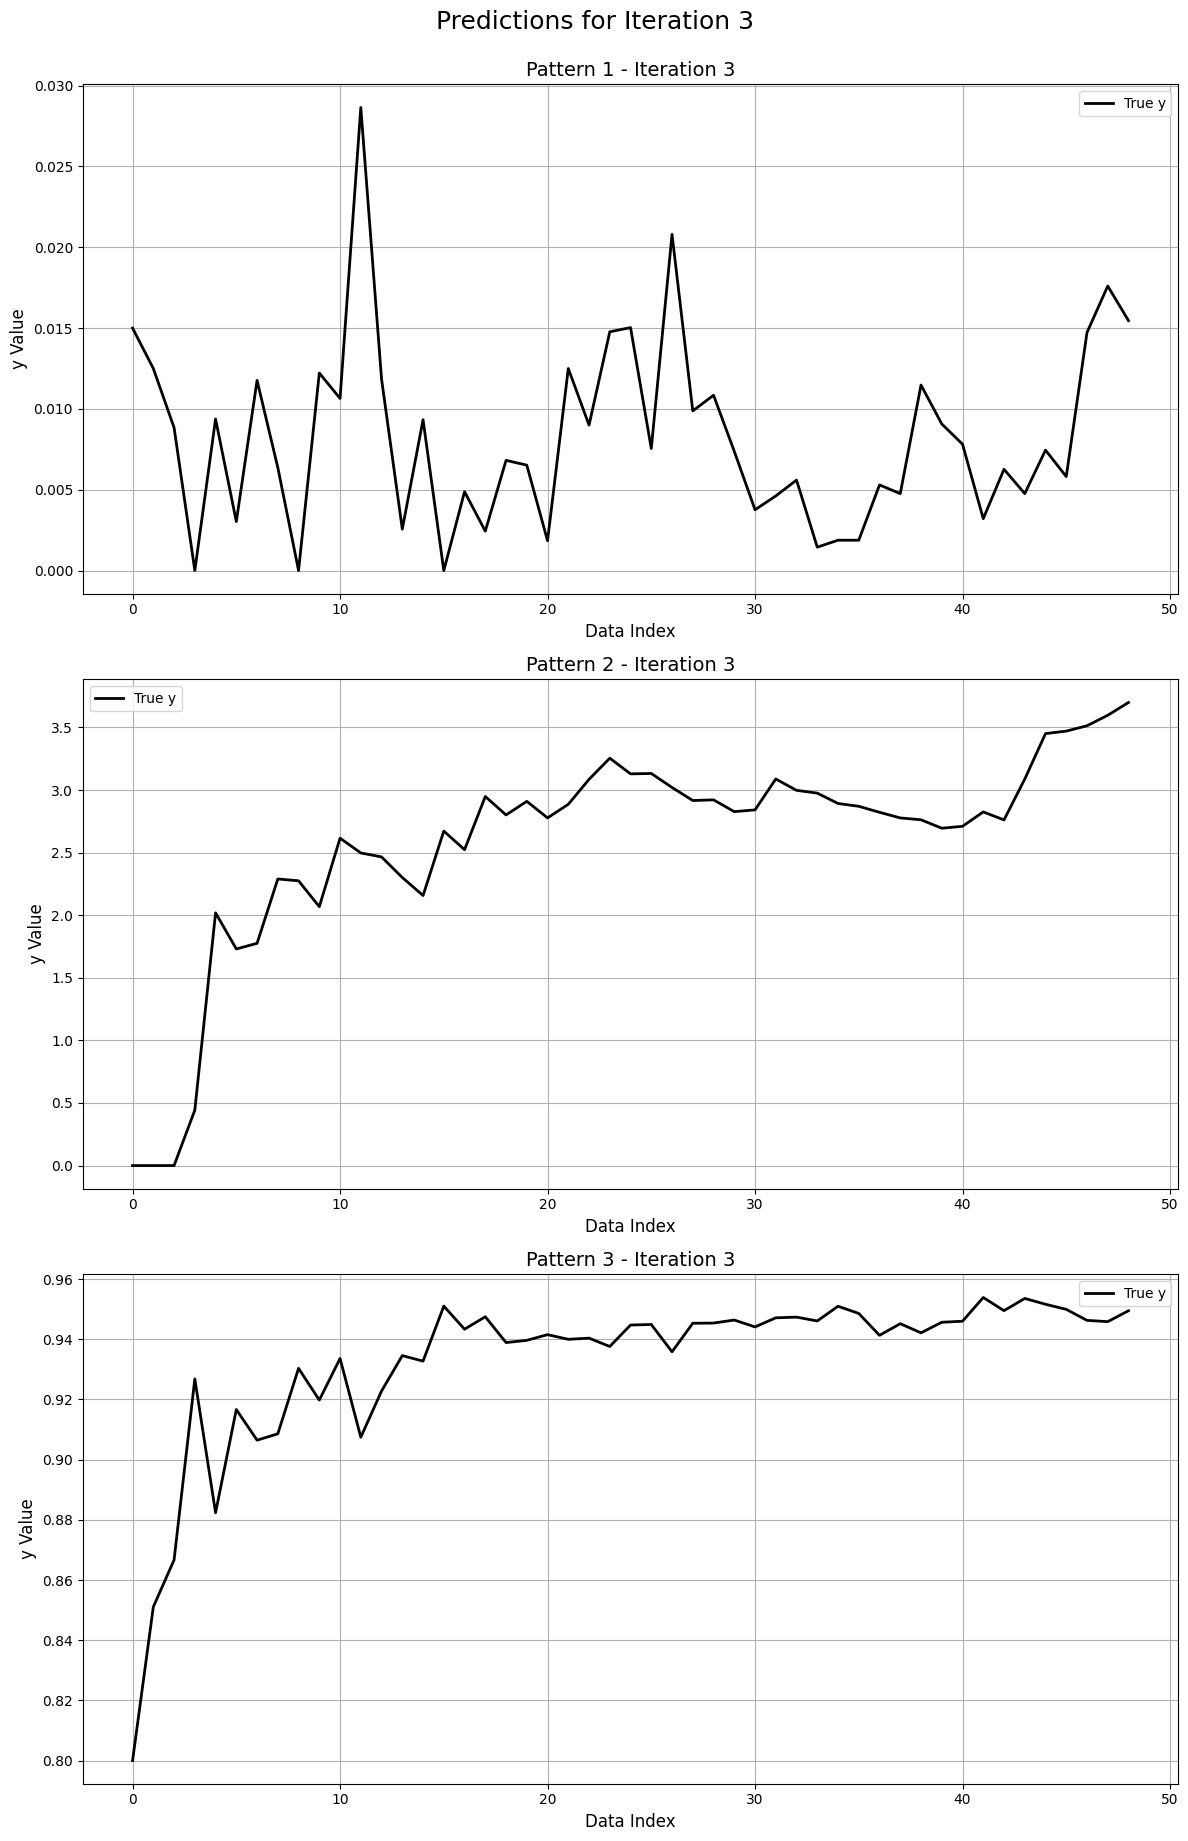

Iteration:3
SciPy feedback used for this iteration:
[[], [{'equation': 'x1+movavg(1, 3)*x3', 'complexity': 5, 'nmae': np.float64(0.375202524848738), 'fitted_params': []}, {'equation': 'log(x1+x2)-x3', 'complexity': 6, 'nmae': np.float64(0.1569790562612386), 'fitted_params': []}], [{'equation': '1/(1+exp(-(x1-x3)))', 'complexity': 10, 'nmae': np.float64(0.3171038758771126), 'fitted_params': []}, {'equation': '1/(1+exp(-(x1+x3)))', 'complexity': 10, 'nmae': np.float64(0.3138574287120163), 'fitted_params': []}]]
LLM thoughts:
To analyze the dataset and suggest new equations, let's break down the information for each pattern:

**Pattern 1 Analysis:**
The dependent variable is the average compute load for the next time slot, influenced by the current task success ratio, vehicle density, average V2U density, and the compute load in the current and previous slots.

- **Key Observations:**
  - The current task success ratio (x1) might affect the compute load due to task completion efficiency.


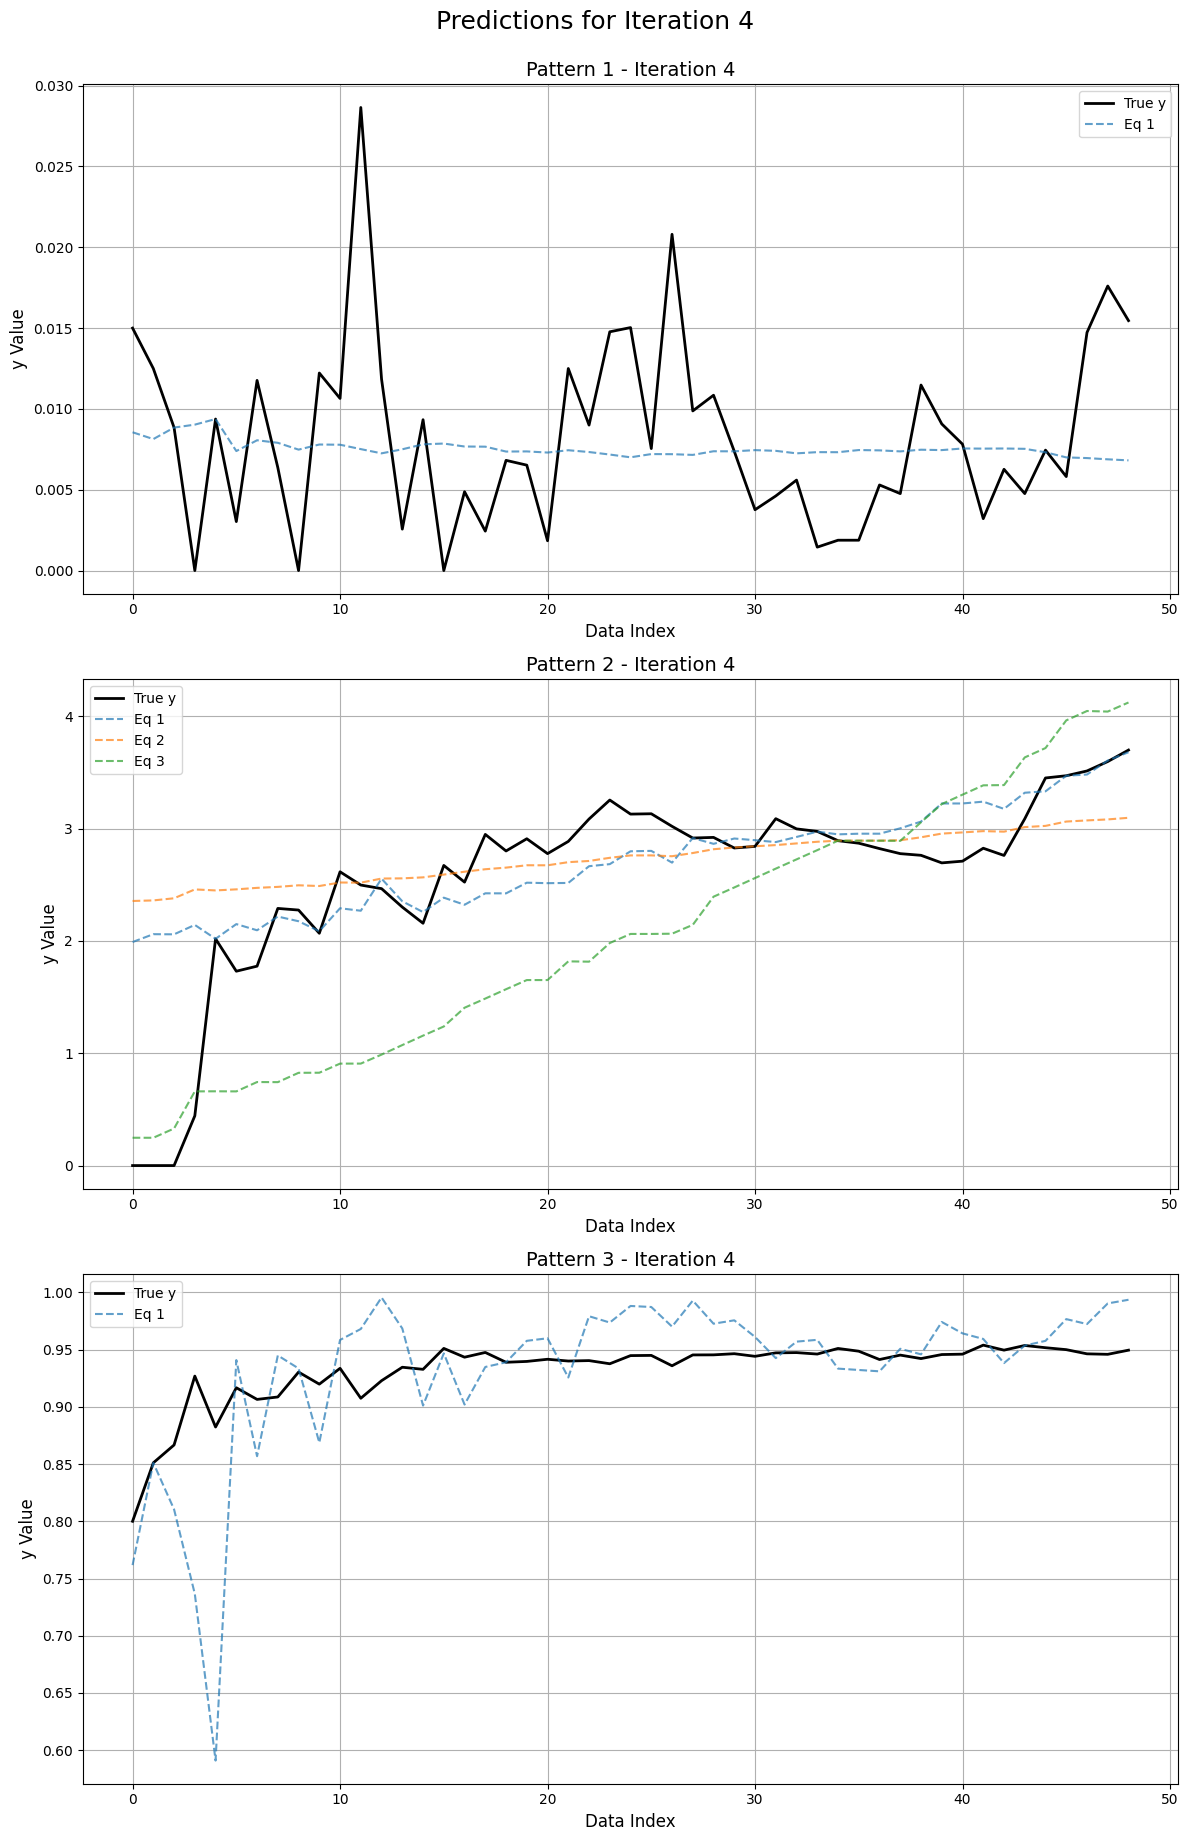

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*x3+c[2]*movavg(1, 3)', 'complexity': 11, 'nmae': np.float64(0.152523445202741), 'fitted_params': [0.014997034098105214, -0.0008024052035758753, -0.004730188558618187]}], [{'equation': 'x1+movavg(1, 3)*x3', 'complexity': 5, 'nmae': np.float64(0.375202524848738), 'fitted_params': []}, {'equation': 'log(x1+x2)-x3', 'complexity': 6, 'nmae': np.float64(0.1569790562612386), 'fitted_params': []}, {'equation': 'c[0]*x1+c[1]*x2+c[2]*x3', 'complexity': 11, 'nmae': np.float64(0.09644292895574177), 'fitted_params': [0.2341931267498195, 0.24316110973957272, 13.984940163343342]}, {'equation': 'c[0]*log(x1+x2)+x3', 'complexity': 8, 'nmae': np.float64(0.11113343684852492), 'fitted_params': [1.1546651888595632]}, {'equation': 'c[0]*x1/(x2+x3)', 'complexity': 7, 'nmae': np.float64(0.21185686373467164), 'fitted_params': [4.133053756354208]}], [{'equation': '1/(1+exp(-(x1-x3)))', 'complexity': 10, 'nmae': np.float64(0.3171038

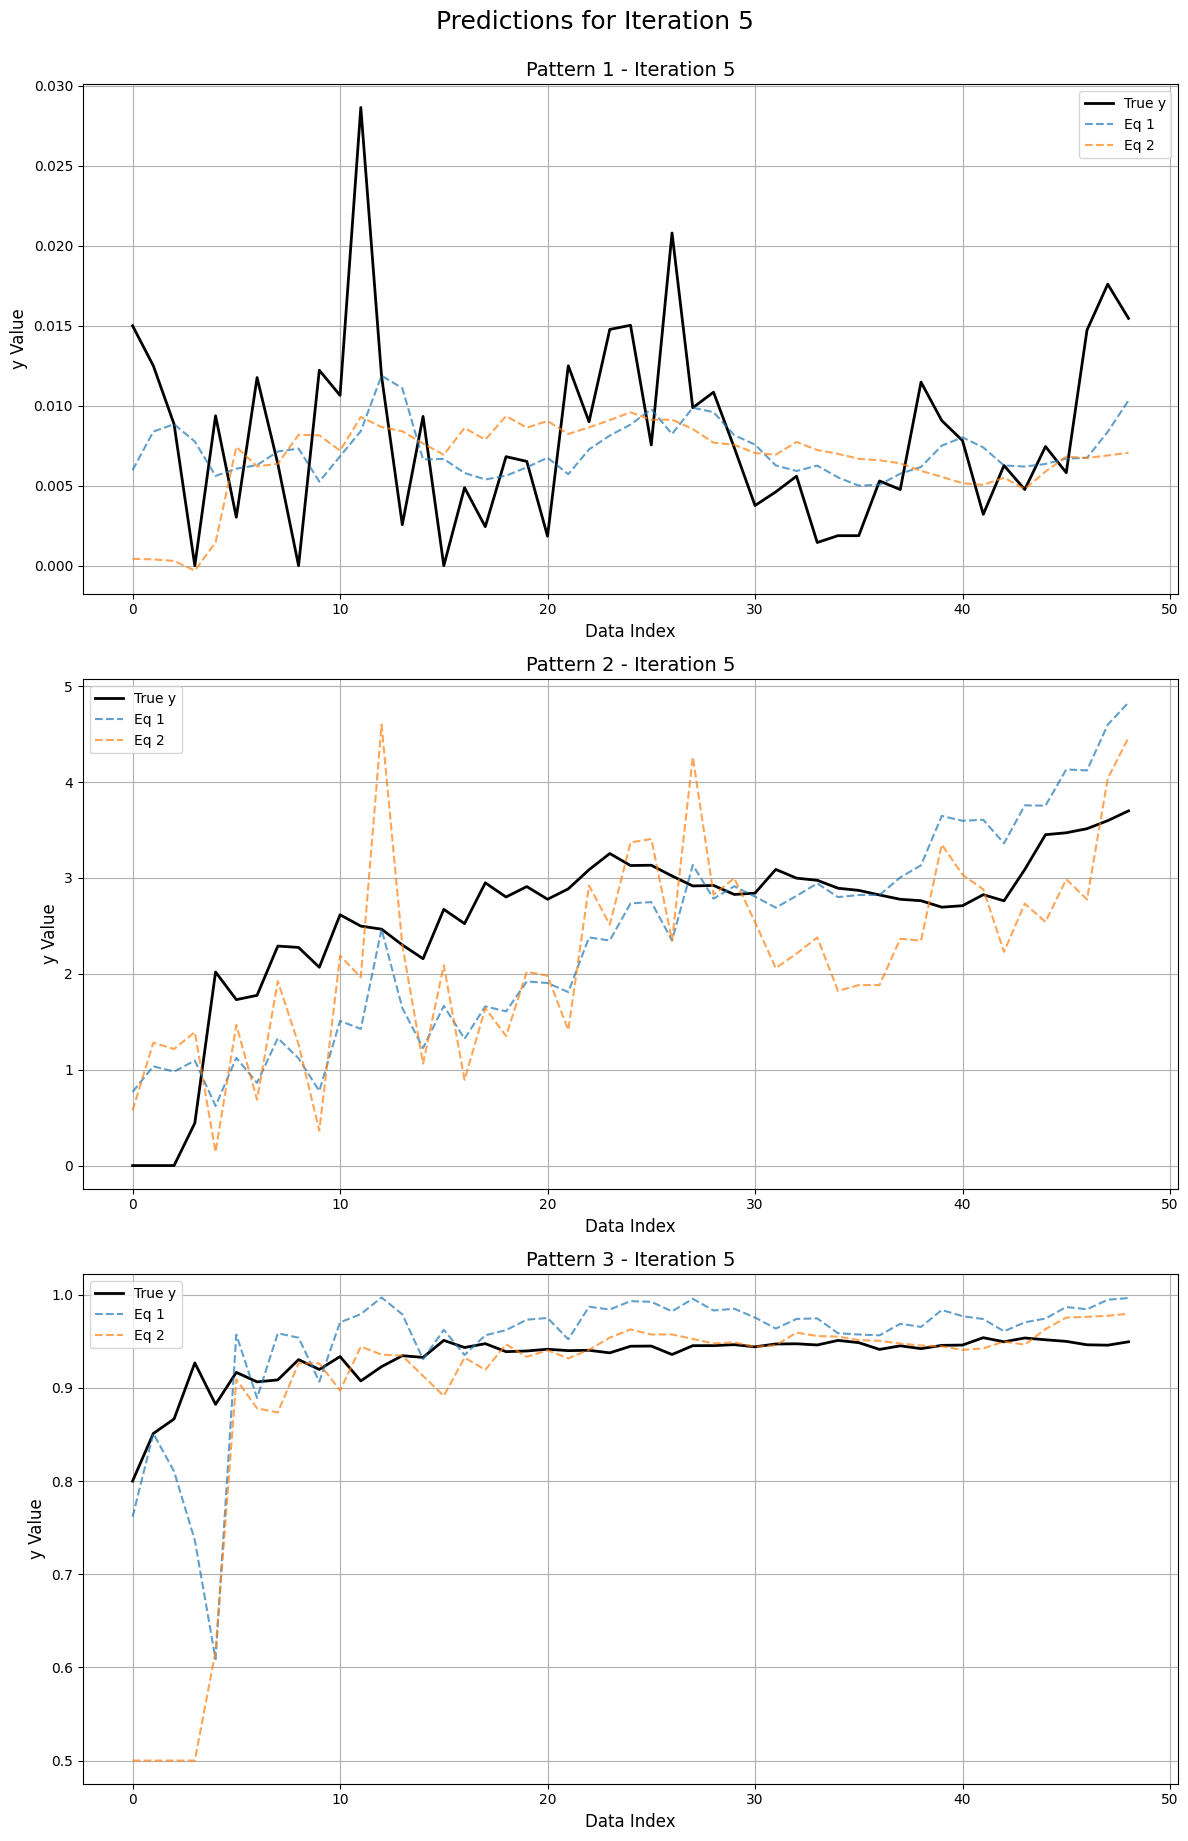

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*x3+c[2]*movavg(1, 3)', 'complexity': 11, 'nmae': np.float64(0.152523445202741), 'fitted_params': [0.014997034098105214, -0.0008024052035758753, -0.004730188558618187]}, {'equation': 'c[0]*x1+c[1]*x4+c[2]*x5', 'complexity': 11, 'nmae': np.float64(0.1384420585531621), 'fitted_params': [0.004615842400442691, 0.21238558522208392, 0.15087314474416208]}, {'equation': 'c[0]*(x1-x2)+c[1]*x3', 'complexity': 9, 'nmae': np.float64(0.1646991950464873), 'fitted_params': [0.0010706870618859424, 0.00382220963026222]}], [{'equation': 'x1+movavg(1, 3)*x3', 'complexity': 5, 'nmae': np.float64(0.375202524848738), 'fitted_params': []}, {'equation': 'c[0]*x1/(x2+x3)', 'complexity': 7, 'nmae': np.float64(0.21185686373467164), 'fitted_params': [4.133053756354208]}, {'equation': 'c[0]*x1+c[1]*x2*x3', 'complexity': 9, 'nmae': np.float64(0.18559096365220948), 'fitted_params': [0.5404782681188731, 7.4355965300989]}, {'equation': 'lo

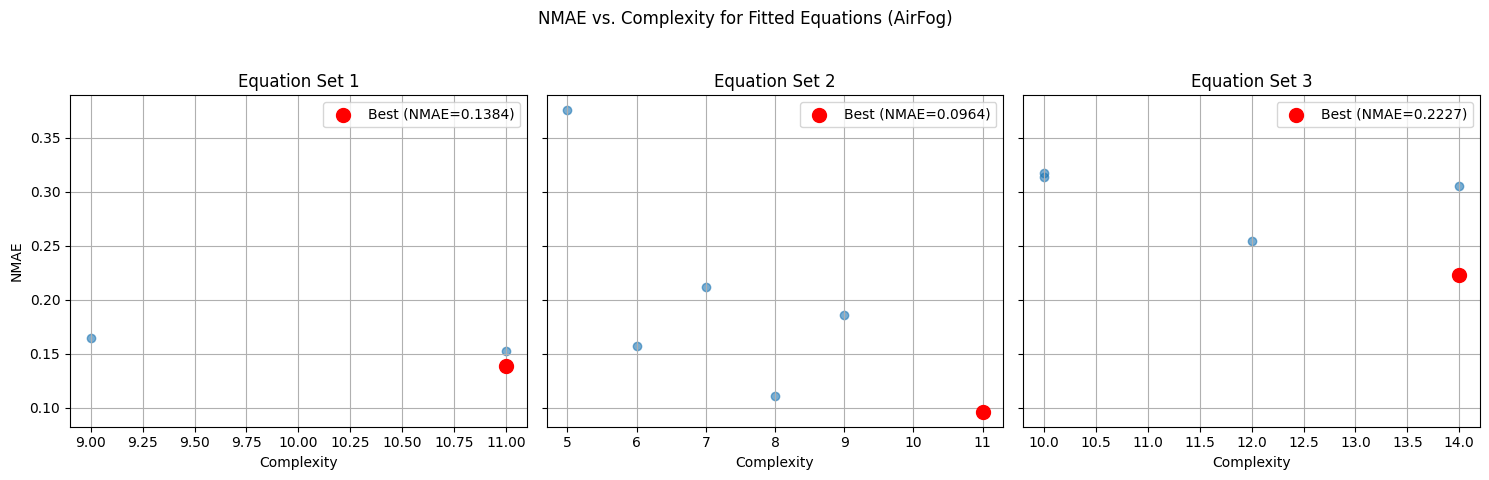

Experiment 3 finished.


In [7]:
import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "results/train"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

    with open(f"{directory_path}/run{i+1}.json", 'w') as json_file:
        json.dump(results, json_file, indent=2)

In [1]:
from helper import format_and_parse_expression_matrix, format_expressions

llm_ord_output = '[[c[0]*x1**2 + c[1]*x3 + movavg(x4, 3), c[0]*(x1-x5) + movavg(x2, 3) + x4, c[0]*x1**2 + c[1]*x2 + c[2]*(x4-x5)], [c[0]*x1 + c[1]*log(x2) + x3, c[0]*x1**2 + c[1]*x2 + x3**2, c[0]*x1 + c[1]*x2**3], [1/(1+exp(-c[0]*x1)), min(1,max(0,c[0]*x2+c[1]*x3)), c[0]*x1 + c[1]*x2*x3]]'
llm_array_output = '\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1^2 + c_1 \\cdot \\log(x_2) + c_2 \\cdot (x_4 + x_5 + x_6)", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2^3 + c_2 \\cdot \\sqrt{x_3}", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_4^2"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1 \\cdot x_2 + c_1 \\cdot x_3", \\\\\n"c_0 \\cdot x_1^2 + c_1 \\cdot x_2^2 + c_2 \\cdot x_3", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot \\log(x_3)"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"1 / (1 + \\exp(-(c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3)))", \\\\\n"\\min(1, \\max(0, c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3))", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3"\n\\end{array}\n\\right] \\]'
llm_bmatrix_output = """\\[
\\begin{bmatrix}
\\text{Pattern 1:} & \\left[ \\text{"x1^2 + x2*x3"}, \\, \\text{"\\log(x1 + x2) + \\sqrt{x3}"}, \\, \\text{"x1*x2 + \\frac{x3}{x1}"} \\right] \\\\
\\text{Pattern 2:} & \\left[ \\text{"x1 + x3"}, \\, \\text{"\\exp(x1) - x2"}, \\, \\text{"x1*x3 - \\log(x2)"} \\right] \\\\
\\text{Pattern 3:} & \\left[ \\text{"\\frac{1}{1 + \\exp(-x1)}"}, \\, \\text{"\\min(1, \\max(0, x1 + x2 - x3))"}, \\, \\text{"\\frac{x1}{1 + x3}"} \\right]
\\end{bmatrix}
\\]"""
llm_align_output = '\\[ \n\\begin{align*}\n\\text{Pattern 1:} \\\\\n& y1 = c_0 \\cdot x1^2 + c_1 \\cdot movavg(x2, 3) + c_2 \\cdot log(x4 + x5), \\\\\n& y2 = c_0 \\cdot x1 \\cdot x2 + c_1 \\cdot x3^2 + c_2 \\cdot sqrt(x6), \\\\\n& y3 = c_0 \\cdot log(x1 + x2) + c_1 \\cdot movavg(x5, 2) + c_2 \\cdot x4 \\cdot x6; \\\\\n\\text{Pattern 2:} \\\\\n& y1 = c_0 \\cdot x1 \\cdot x3 + c_1 \\cdot sqrt(x2), \\\\\n& y2 = c_0 \\cdot x1^2 + c_1 \\cdot x3^2 + c_2 \\cdot movavg(x1, 4), \\\\\n& y3 = c_0 \\cdot log(x1) + c_1 \\cdot x2 \\cdot x3; \\\\\n\\text{Pattern 3:} \\\\\n& y1 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot x2 + c_2 \\cdot x3))}, \\\\\n& y2 = \\min(1, \\max(0, c_0 \\cdot x1^2 + c_1 \\cdot x2 + c_2 \\cdot \\log(x3))), \\\\\n& y3 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot \\sqrt{x2) + c_2 \\cdot x3))}.\n\\end{align*}\n\\]'

# Parse the LLM output
parsed_matrix = format_and_parse_expression_matrix(llm_ord_output)
# Print the parsed matrix
for row in parsed_matrix:
    print("Parsed Row:")
    print(row)
    print("Formatted Row:")
    print(format_expressions(row))
    print("\n")


ValueError: Unsupported expression format:
[[c[0]*x1**2 + c[1]*x3 + movavg(x4, 3), c[0]*(x1-x5) + movavg(x2, 3) + x4, c[0]*x1**2 + c[1]*x2 + c[2]*(x4-x5)], [c[0]*x1 + c[1]*log(x2) + x3, c[0]*x1**2 + c[1]*x2 + x3**2, c[0]*x1 + c[1]*x2**3], [1/(1+exp(-c[0]*x1)), min(1,max(0,c[0]*x2+c[1]*x3)), c[0]*x1 + c[1]*x2*x3]]